# Bank Marketing Analysis Project

## Introduction

This project focuses on the **Bank Marketing Dataset**, which contains information about customers contacted during a marketing campaign for term deposits. The dataset includes **21 features** ranging from customer demographics (age, job, marital status, education) to financial indicators (housing and personal loans) and macroeconomic variables (employment variation rate, consumer price index, euribor3m rate, number of employed).

### Project Objective

The main objective of this project is to explore and analyze customer behavior to identify factors influencing **term deposit subscriptions**. The analysis is divided into two main phases:

1. **Exploratory Data Analysis (EDA):** 
   - Understanding the **distribution of features**, including both numerical and categorical variables.
   - Identifying trends, patterns, and potential outliers.
   - Visualizing key relationships using **histograms, boxplots, bar charts, and correlation heatmaps**.
   - Investigating customer subscription rates across different demographic and economic groups.

2. **Predictive Modeling (Machine Learning):**
   - Preparing the dataset for machine learning by encoding categorical variables and handling missing values (if applicable).
   - Building predictive models to estimate the likelihood of a customer subscribing to a term deposit.
   - Evaluating model performance using appropriate metrics.

### Workflow

- **Data Collection:** Extracted the dataset from the BankMarketingDB.
- **Data Cleaning and Preprocessing:** Ensured data quality, handled outliers, and prepared features for analysis.
- **Exploratory Data Analysis:** Performed comprehensive EDA to understand customer patterns and behaviors.
- **Feature Engineering:** Created new features where appropriate to improve model insights.
- **Modeling:** Applied predictive models (such as logistic regression and ensemble methods) to predict subscription behavior.
- **Interpretation:** Provided actionable insights from EDA and model results to understand which factors influence customer decisions.

This notebook documents the complete workflow from initial **EDA** to **machine learning modeling**, providing a clear understanding of customer behavior and factors affecting term deposit subscriptions.

---
**Author** Sina Rastegar

**Date:** April 25, 2026


## Environment & Dependencies

This project was developed in a Jupyter Notebook environment and relies on the following libraries:


In [1]:
# ==============================
# Imports & Global Configuration
# ==============================

# Core Data
import numpy as np
import pandas as pd
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
%matplotlib inline

# Files 
from pathlib import Path

# Database (SQL Server)
from sqlalchemy import create_engine

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn import set_config
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    precision_recall_curve,
    auc,
    confusion_matrix
)

In [2]:
# ==============================
# Global Visualization Settings
# ==============================

plt.rcParams.update({
    "figure.dpi": 120,              
    "savefig.dpi": 300,            
    "savefig.bbox": "tight",        
    "savefig.transparent": True     
})

FIGURES_DIR = Path("..") / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

## Data Collection and Preprocessing

The raw data was first **imported into SQL**, where the database and tables were created. Initial preprocessing steps were performed, including:

- **Checking for duplicates** and ensuring data integrity.
- Performing basic **data cleaning** to standardize formats and remove inconsistencies.

```sql
CREATE TABLE BankMarketingData (
    age INT,
    job NVARCHAR(100),
    marital_status NVARCHAR(50),
    education_level NVARCHAR(50),
    has_default NVARCHAR(10),
    has_housing_loan NVARCHAR(10),
    has_personal_loan NVARCHAR(10),
    contact_method NVARCHAR(50),
    last_contact_month NVARCHAR(20),
    last_contact_day_of_week NVARCHAR(20),
    contact_duration INT,
    campaign_contacts INT,
    days_since_last_contact INT,
    previous_campaign_contacts INT,
    previous_campaign_outcome NVARCHAR(50),
    employment_variation_rate FLOAT,
    consumer_price_index FLOAT,
    consumer_confidence_index FLOAT,
    euribor3m_rate FLOAT,
    nr_employed FLOAT,
    subscribed NVARCHAR(10)
);
'''


```sql
BULK INSERT BankMarketingData
FROM 'D:...\bank-additional-full.csv'
WITH (
    FIELDTERMINATOR = ';',
    ROWTERMINATOR = '\n',
    FIRSTROW = 2
);
```

```sql
UPDATE BankMarketingData
SET job = REPLACE(job, '"', ''),
    marital_status = REPLACE(marital_status, '"', ''),
    education_level = REPLACE(education_level, '"', ''),
    has_default = REPLACE(has_default, '"', ''),
    has_housing_loan = REPLACE(has_housing_loan, '"', ''),
    has_personal_loan = REPLACE(has_personal_loan, '"', ''),
    contact_method = REPLACE(contact_method, '"', ''),
    last_contact_month = REPLACE(last_contact_month, '"', ''),
    last_contact_day_of_week = REPLACE(last_contact_day_of_week, '"', '');
```


```sql
UPDATE BankMarketingData
SET job = REPLACE(job, '"', ''),
    marital_status = REPLACE(marital_status, '"', ''),
    education_level = REPLACE(education_level, '"', ''),
    has_default = REPLACE(has_default, '"', ''),
    has_housing_loan = REPLACE(has_housing_loan, '"', ''),
    has_personal_loan = REPLACE(has_personal_loan, '"', ''),
    contact_method = REPLACE(contact_method, '"', ''),
    last_contact_month = REPLACE(last_contact_month, '"', ''),
    last_contact_day_of_week = REPLACE(last_contact_day_of_week, '"', '');
```

Explanation of Duplicate Data

During the data review process, I found that 15 records were duplicated, meaning that all their features were identical and appeared twice. These 15 records have the same information for each customer and were repeated in the dataset.

Decision:

After reviewing the dataset, I couldn't find any official information on the UCI Bank Marketing Dataset website about whether similar customers should be considered duplicates.

Therefore, the duplicate nature of these records remained unclear.

Given that the number of duplicated records was only 15 and their proportion relative to the total dataset (41,188 records) is small, I decided not to remove them.

I assumed that these may be distinct customers with identical characteristics. Since the number of duplicated records was small and unlikely to significantly affect the analysis, I chose to keep them.


After the initial cleanup in SQL, the dataset was **imported into Python (Pandas)** for further analysis. A connection between SQL and Python was established to enable smooth data extraction and manipulation for **Exploratory Data Analysis (EDA)** and subsequent modeling.


In [3]:
connection_string = (
    "mssql+pyodbc://localhost/BankMarketingDB?"
    "driver=ODBC+Driver+17+for+SQL+Server"
)

engine = create_engine(connection_string)


In [4]:
query = """
    SELECT [age]
      ,[job]
      ,[marital_status]
      ,[education_level]
      ,[has_default]
      ,[has_housing_loan]
      ,[has_personal_loan]
      ,[contact_method]
      ,[last_contact_month]
      ,[last_contact_day_of_week]
      ,[contact_duration]
      ,[campaign_contacts]
      ,[days_since_last_contact]
      ,[previous_campaign_contacts]
      ,[previous_campaign_outcome]
      ,[employment_variation_rate]
      ,[consumer_price_index]
      ,[consumer_confidence_index]
      ,[euribor3m_rate]
      ,[nr_employed]
      ,[subscribed]
  FROM [BankMarketingDB].[dbo].[BankMarketingData]
"""

df_bank_marketing = pd.read_sql(query, engine)
pd.set_option('display.max_columns', None)

df_bank_marketing

,age,job,marital_status,education_level,has_default,has_housing_loan,has_personal_loan,contact_method,last_contact_month,last_contact_day_of_week,contact_duration,campaign_contacts,days_since_last_contact,previous_campaign_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor3m_rate,nr_employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Exploratory Data Analysis


In [5]:
df_bank_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         41188 non-null  int64  
 1   job                         41188 non-null  object 
 2   marital_status              41188 non-null  object 
 3   education_level             41188 non-null  object 
 4   has_default                 41188 non-null  object 
 5   has_housing_loan            41188 non-null  object 
 6   has_personal_loan           41188 non-null  object 
 7   contact_method              41188 non-null  object 
 8   last_contact_month          41188 non-null  object 
 9   last_contact_day_of_week    41188 non-null  object 
 10  contact_duration            41188 non-null  int64  
 11  campaign_contacts           41188 non-null  int64  
 12  days_since_last_contact     41188 non-null  int64  
 13  previous_campaign_contacts  411

In [6]:
df_bank_marketing.isna().sum()

age                           0
job                           0
marital_status                0
education_level               0
has_default                   0
has_housing_loan              0
has_personal_loan             0
contact_method                0
last_contact_month            0
last_contact_day_of_week      0
contact_duration              0
campaign_contacts             0
days_since_last_contact       0
previous_campaign_contacts    0
previous_campaign_outcome     0
employment_variation_rate     0
consumer_price_index          0
consumer_confidence_index     0
euribor3m_rate                0
nr_employed                   0
subscribed                    0
dtype: int64

In [7]:
categorical_columns = ['job', 'marital_status', 'education_level', 'has_default', 
                       'has_housing_loan', 'has_personal_loan', 'contact_method', 
                       'last_contact_month', 'last_contact_day_of_week', 'previous_campaign_outcome', 
                       'subscribed']

unknown_counts = df_bank_marketing[categorical_columns].apply(lambda col: col[col == 'unknown'].count())

unknown_counts

job                           330
marital_status                 80
education_level              1731
has_default                  8597
has_housing_loan              990
has_personal_loan             990
contact_method                  0
last_contact_month              0
last_contact_day_of_week        0
previous_campaign_outcome       0
subscribed                      0
dtype: int64

### Subscription Rate Overview

In [8]:
df_bank_marketing['subscribed'] = df_bank_marketing['subscribed'].map({'no': 0, 'yes': 1})

In [9]:
subscription_rate = (
    df_bank_marketing['subscribed']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

subscription_rate

,subscribed,proportion
0,0,88.73
1,1,11.27



The **subscription rate** of customers was calculated as follows:

| Subscribed | Proportion (%) |
|------------|----------------|
| 0          | 88.73          |
| 1          | 11.27          |

### Interpretation:

- Only **11.27% of customers** subscribed to term deposits, indicating a **highly imbalanced dataset**.  
- This imbalance is a critical observation for both **data analysis** and **future predictive modeling**, as special care might be needed when building classification models to avoid bias toward the majority class.


In [10]:
df_bank_marketing['last_contact_month'].value_counts()

last_contact_month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [11]:
subscription_rate_trend_yearly = (
    df_bank_marketing.groupby('last_contact_month')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .reset_index()
)

months_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

subscription_rate_trend_yearly["last_contact_month"] = pd.Categorical(
    subscription_rate_trend_yearly["last_contact_month"] , categories=months_order , ordered=True)

subscription_rate_trend_yearly = subscription_rate_trend_yearly.sort_values("last_contact_month")

subscription_rate_trend_yearly

,last_contact_month,subscription_rate
5,mar,50.55
0,apr,20.48
6,may,6.43
4,jun,10.51
3,jul,9.05
1,aug,10.60
9,sep,44.91
8,oct,43.87
7,nov,10.14
2,dec,48.90


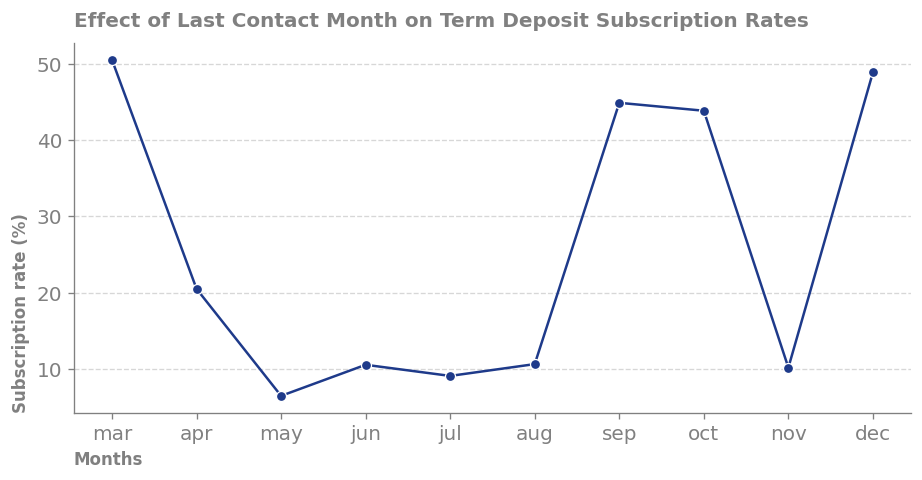

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

ax = sns.lineplot(
    data=subscription_rate_trend_yearly,
    x="last_contact_month",
    y="subscription_rate",
    marker="o",
    color='#1E3A8A'
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Effect of Last Contact Month on Term Deposit Subscription Rates",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,
    pad=10
)
ax.set_xlabel("Months"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax.set_ylabel("Subscription rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.savefig(FIGURES_DIR / "1.png")
plt.show()

The subscription rates were calculated for each month based on the `last_contact_month` feature. 

### Observations:
- **March, September, and October** show higher subscription rates compared to other months.
- **May and November** have notably lower subscription rates.
- These fluctuations suggest that **the timing of customer contact may influence subscription behavior**, which can provide actionable insights for scheduling marketing campaigns.


In [13]:
df_bank_marketing['last_contact_day_of_week'].value_counts()

last_contact_day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64

In [14]:
subscription_rate_trend_weekly = (
    df_bank_marketing.groupby('last_contact_day_of_week')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .reset_index()
)

days_order = ["mon" , "tue" , "wed" , "thu" , "fri"]

subscription_rate_trend_weekly["last_contact_day_of_week"] = pd.Categorical(
    subscription_rate_trend_weekly["last_contact_day_of_week"] , categories=days_order , ordered=True)

subscription_rate_trend_weekly = subscription_rate_trend_weekly.sort_values("last_contact_day_of_week")

subscription_rate_trend_weekly

,last_contact_day_of_week,subscription_rate
1,mon,9.95
3,tue,11.78
4,wed,11.67
2,thu,12.12
0,fri,10.81


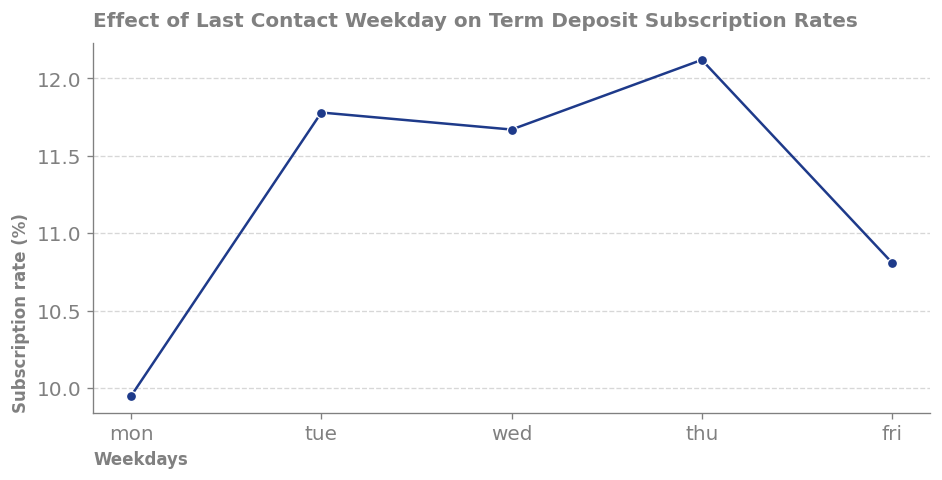

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))

ax = sns.lineplot(
    data=subscription_rate_trend_weekly,
    x="last_contact_day_of_week",
    y="subscription_rate",
    marker="o",
    color='#1E3A8A'
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Effect of Last Contact Weekday on Term Deposit Subscription Rates",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,    
    pad=10
)
ax.set_xlabel("Weekdays"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax.set_ylabel("Subscription rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.savefig(FIGURES_DIR / "2.png")
plt.show()

The subscription rates were calculated for each weekday based on the `last_contact_day_of_week` feature.

### Observations:
- **Tuesday and Thursday** show relatively higher subscription rates.
- **Monday** shows a lower subscription rate compared to other weekdays.
- This suggests that **the day of the week when customers are contacted may influence subscription behavior**, which can inform marketing campaign scheduling and resource allocation.


### Customer Age Distribution Analysis

In [16]:
df_bank_marketing['age'].describe()

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

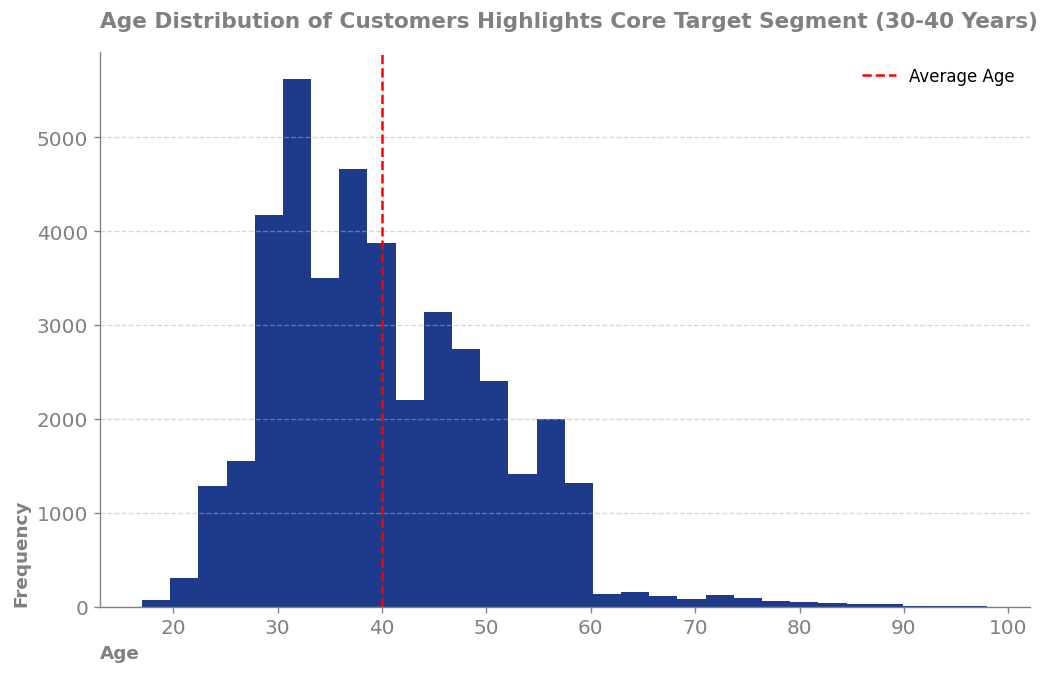

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(df_bank_marketing['age'], 
         bins=30, 
         color='#1E3A8A')

plt.axvline(df_bank_marketing['age'].mean(),
            linestyle='--', linewidth=1.5, color='red', label='Average Age')

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

plt.title(
    "Age Distribution of Customers Highlights Core Target Segment (30-40 Years)",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=13,    
    pad=15
)
plt.xlabel("Age", 
           loc="left", 
           weight="bold", 
           color="gray", 
           fontsize=11)
plt.ylabel("Frequency", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=11)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.legend(frameon=False)

plt.savefig(FIGURES_DIR / "3.png")
plt.show()

This histogram shows the age distribution of all bank customers.

### Key Insights:
- The distribution is left-skewed, with the majority of customers aged between 30 and 40.
- The average age of customers is around 40 years.
- Customers below 20 and above 60 represent a smaller proportion of the population.
- **Business Implication:** Marketing campaigns should prioritize the 30-40 age group to maximize impact and efficiency, while adjusting strategies for younger or older demographics.


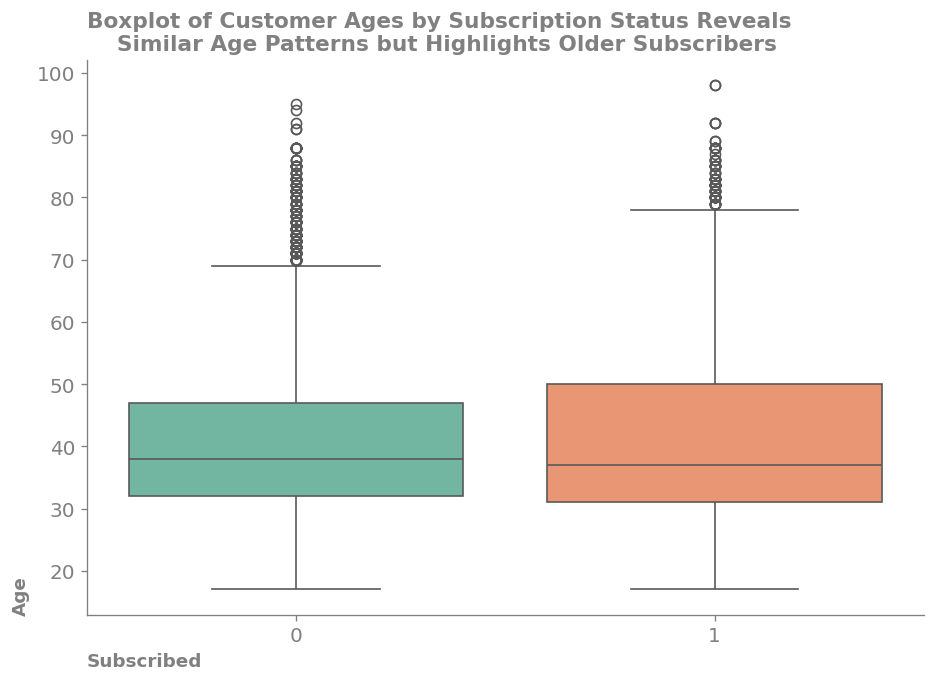

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(x='subscribed', 
            y='age', 
            data=df_bank_marketing, 
            hue='subscribed',
            palette='Set2',
            legend=False)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

plt.title(
    "Boxplot of Customer Ages by Subscription Status Reveals\n\
    Similar Age Patterns but Highlights Older Subscribers",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=13,
)
plt.xlabel("Subscribed", 
           loc="left", 
           weight="bold", 
           color="gray", 
           fontsize=11)
plt.ylabel("Age", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=11)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.savefig(FIGURES_DIR / "4.png")
plt.show()

This boxplot compares the age distribution of subscribed vs. non-subscribed customers.

### Key Insights:
- Median and mean ages are similar between subscribed and non-subscribed groups.
- Subscribed customers show slightly wider age range and contain older outliers.
- Outliers (ages >70) are valid data points representing possibly retired or financially independent customers.
- **Business Implication:** Age alone is not a strong differentiator for subscription; focus should also consider job, financial status, and contact history.


In [19]:
stats.skew(df_bank_marketing['age'])

np.float64(0.784668238093229)

In [20]:
z_scores = stats.zscore(df_bank_marketing['age'])

outliers = df_bank_marketing[(z_scores > 3) | (z_scores < -3)]

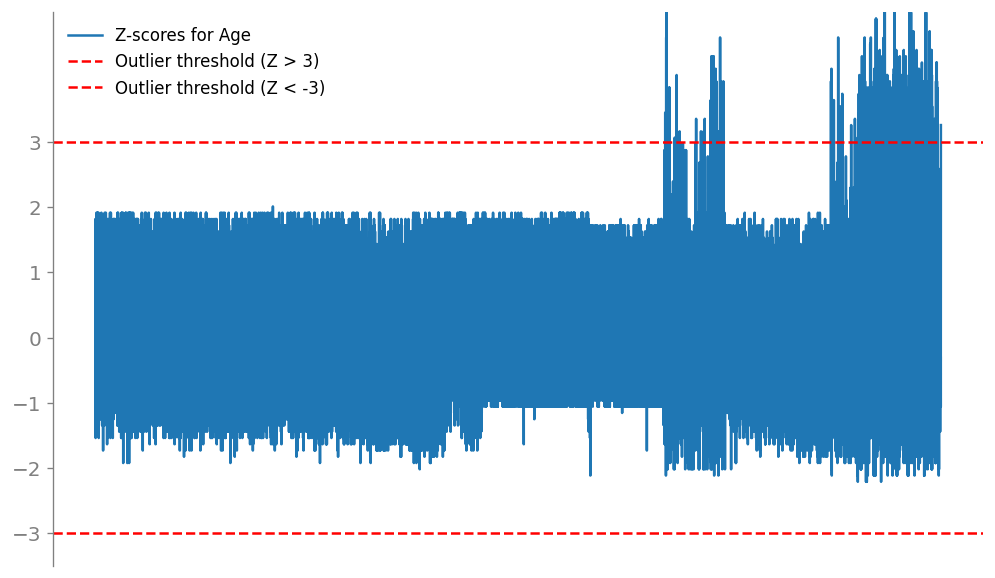

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(z_scores, label="Z-scores for Age")
plt.axhline(y=3, color='r', linestyle='--', label="Outlier threshold (Z > 3)")
plt.axhline(y=-3, color='r', linestyle='--', label="Outlier threshold (Z < -3)")

ax.spines[["right", "top", "bottom"]].set_visible(False)
ax.spines[["left"]].set_color("gray")

ax.set_yticks(np.arange(-3, 3.5, 1))
ax.set_ylim(-3.5, 5)

ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="x", bottom=False, labelbottom=False, labelsize="large")

plt.legend(frameon=False)

plt.savefig(FIGURES_DIR / "5.png")
plt.show()

**Outliers** (ages above 70) were identified, but they were kept in the dataset as they likely represent **retired individuals**, which is logical for the data.


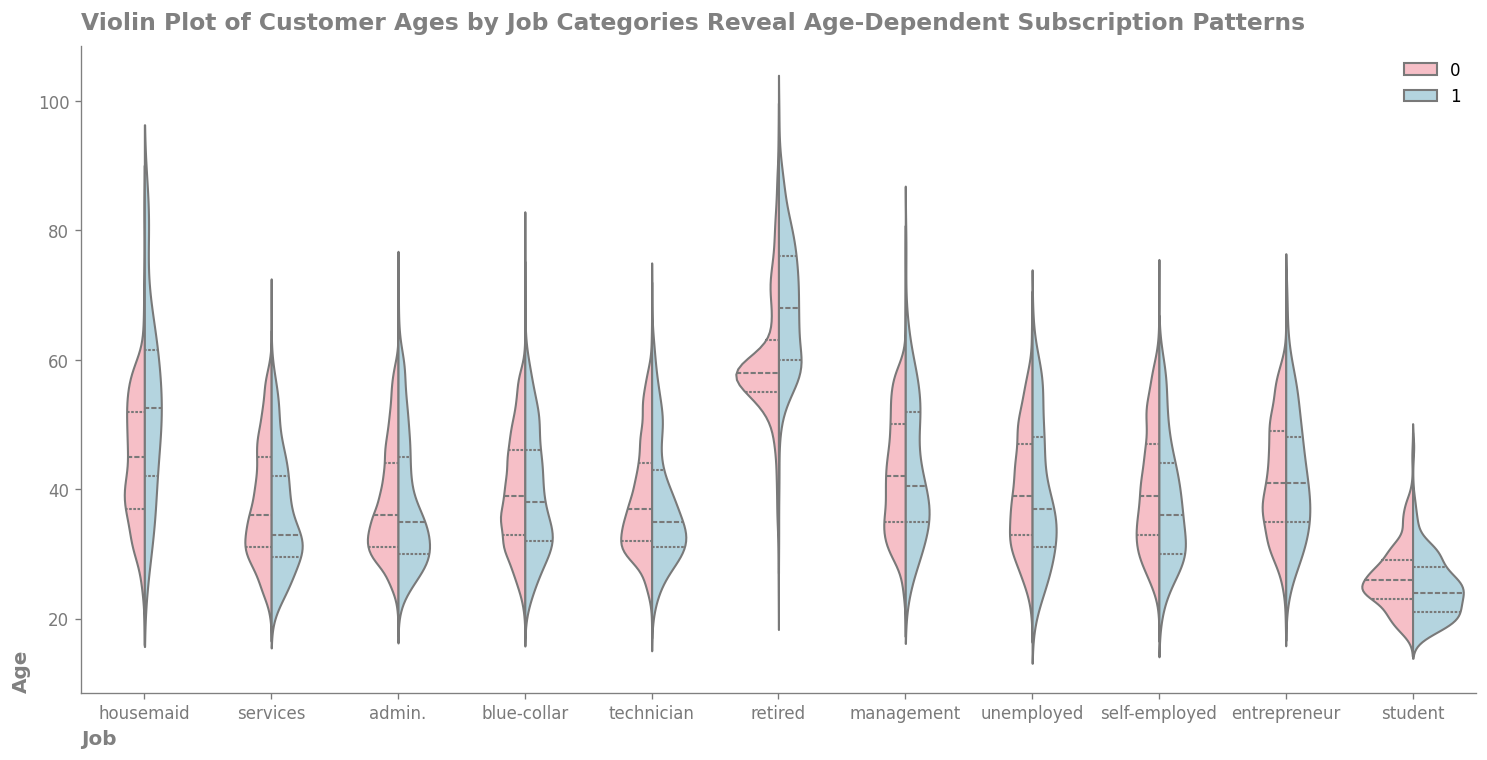

In [22]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.violinplot(y="age", x="job", hue="subscribed", 
               data=df_bank_marketing.query("job!='unknown'"),
               split=True, inner="quartile",
               palette=["lightpink", "lightblue"])

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Violin Plot of Customer Ages by Job Categories Reveal Age-Dependent Subscription Patterns",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=14,
    pad=10
)
ax.set_ylabel("Age", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=12)
ax.set_xlabel("Job", 
           loc="left", 
           weight="bold", 
           color="grey", 
           fontsize=12)

ax.tick_params(axis="x", colors="#7A7A7A")
ax.tick_params(axis="y", colors="#7A7A7A")

ax.legend(frameon=False)

plt.savefig(FIGURES_DIR / "6.png")
plt.show()

This violin plot illustrates the age distribution across different job categories, highlighting subscribed vs. non-subscribed customers.

### Key Insights:
- Retired customers show the highest age and subscription rate.
- Students and younger job categories have lower subscription rates.
- Mid-age job categories like technicians and admins exhibit moderate age spread and balanced subscription rates.
- **Business Implication:** Marketing campaigns can target job categories with lower subscription rates to improve conversion, while leveraging high-rate segments for upselling opportunities.


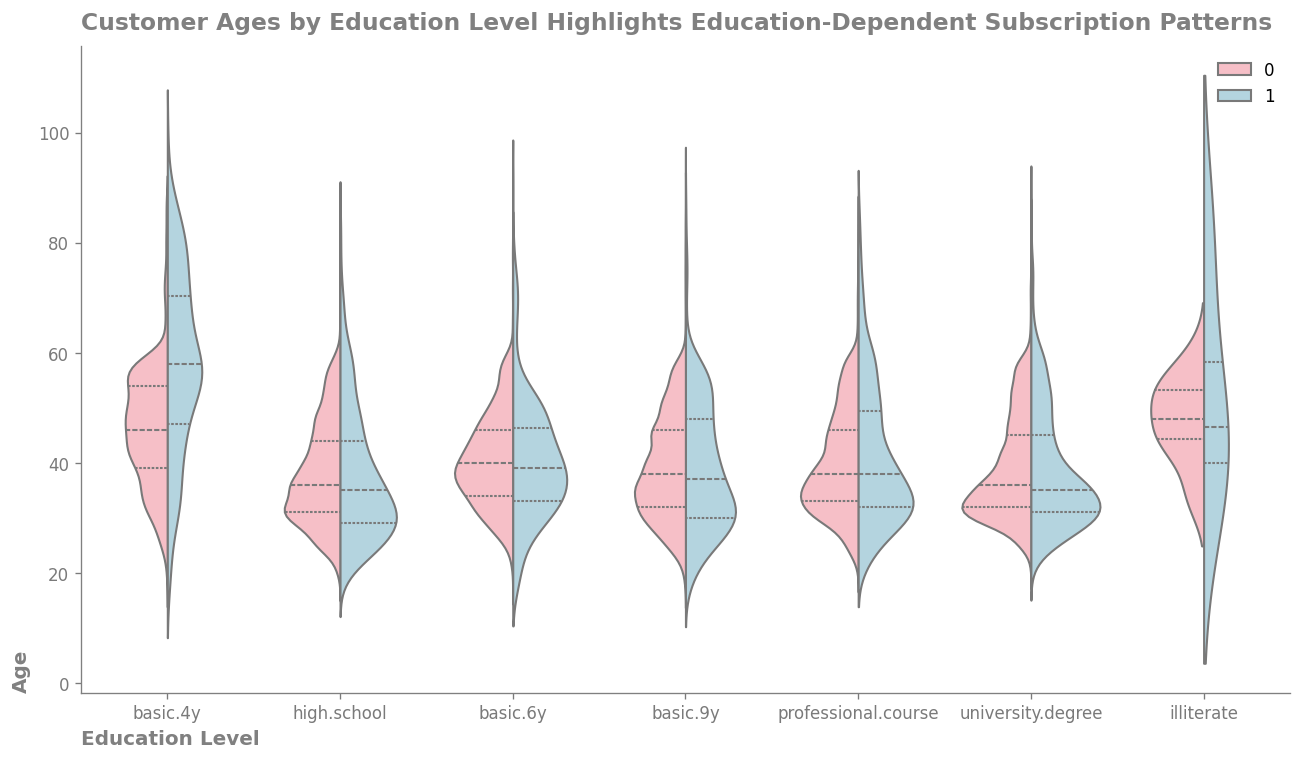

In [23]:
fig, ax = plt.subplots(figsize=(13, 7))

sns.violinplot(y="age", x="education_level", hue="subscribed", 
               data=df_bank_marketing.query("education_level!='unknown'"),
               split=True, inner="quartile",
               palette=["lightpink", "lightblue"])

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Customer Ages by Education Level Highlights Education-Dependent Subscription Patterns",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=14,    
    pad=10
)
ax.set_ylabel("Age", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=12)

ax.set_xlabel("Education Level", 
           loc="left", 
           weight="bold", 
           color="grey", 
           fontsize=12)

ax.tick_params(axis="x", colors="#7A7A7A")
ax.tick_params(axis="y", colors="#7A7A7A")

ax.legend(frameon=False)

plt.savefig(FIGURES_DIR / "7.png")
plt.show()

This violin plot illustrates the age distribution across different education levels, highlighting subscribed vs. non-subscribed customers.

### Key Insights:
- University graduates and professional course participants show moderate ages and balanced subscription rates.
- Illiterate and low-education customers show wide age dispersion and lower subscription rates.
- **Business Implication:** Marketing campaigns can target low-education groups to increase subscription rates, while leveraging higher-education segments for tailored offers.


In [24]:
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['<18', '18-30', '30-40', '40-50', '50-60', '60+']

df_bank_marketing['age_group'] = pd.cut(
    df_bank_marketing['age'],
    bins=bins,
    labels=labels, 
    right=False
)

subscription_rate_by_age = (
    df_bank_marketing.groupby('age_group')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_age

C:\Users\asus\AppData\Local\Temp\ipykernel_13740\1668667752.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bank_marketing.groupby('age_group')


,age_group,subscription_rate
0,<18,40.00
1,60+,39.56
2,18-30,16.24
3,50-60,10.16
4,30-40,10.13
5,40-50,7.92


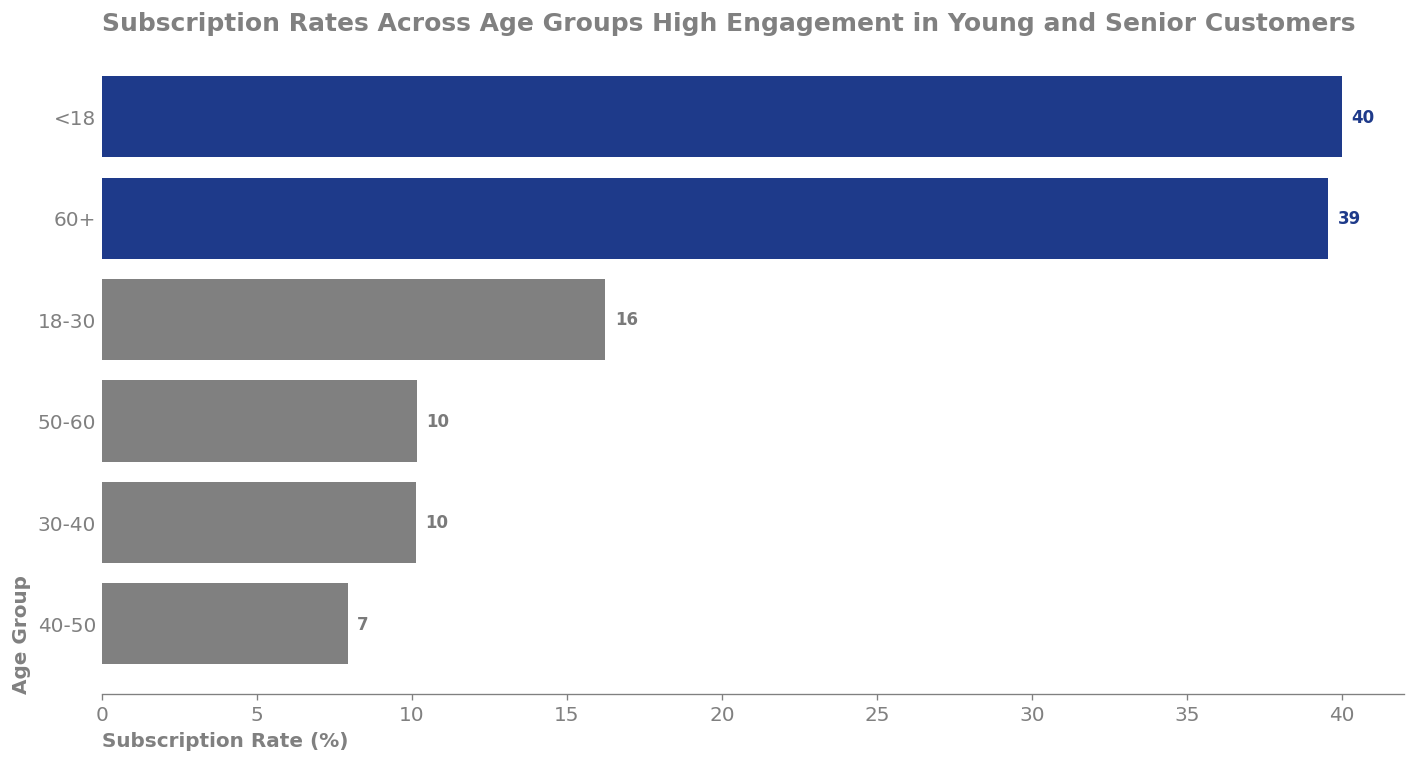

In [25]:
colors = ['#1E3A8A' if i < 2 else '#808080' for i in range(len(subscription_rate_by_age))]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    subscription_rate_by_age['age_group'],
    subscription_rate_by_age['subscription_rate'],
    color=colors
)

ax.invert_yaxis()

for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = "#1E3A8A" if i < 2 else "#7A7A7A"

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines["bottom"].set_color("gray")

plt.title("Subscription Rates Across Age Groups High Engagement in Young and Senior Customers",
          loc="left",
          weight="bold",
          color="gray",
          fontsize=15,
          pad=10
)

plt.ylabel("Age Group", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=12)

plt.xlabel("Subscription Rate (%)", 
           weight="bold", 
           color="gray", 
           loc="left", 
           fontsize=12)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", length=0, labelsize="large")

plt.savefig(FIGURES_DIR / "8.png")
plt.show()

### Subscription Rate by Age Group Key Insights:

- Young (<18) and senior (60+) customers show the highest subscription rates.
- Middle-aged groups (30-50) have lower subscription engagement.
- **Business Implication:** Marketing campaigns can target middle-aged groups to improve conversion, while leveraging high-engagement segments for loyalty programs.


### Analysis by Customer Occupation

This section focuses on exploring customer characteristics based on their job types, to understand how demographics and behaviors vary across occupations.

1. Average Contact Duration by Job

2. Marital Status Distribution Across Occupations


In [26]:
average_contact_duration_per_job = (
    df_bank_marketing.query("job != 'unknown'")
    .groupby("job")
    .agg(average_contact_duration = ("contact_duration" , "mean"))
    .round(2)
    .sort_values('average_contact_duration', ascending=False)
    .reset_index()
)

average_contact_duration_per_job

,job,average_contact_duration
0,student,283.68
1,retired,273.71
2,blue-collar,264.54
3,self-employed,264.14
4,entrepreneur,263.27
5,services,258.40
6,management,257.06
7,admin.,254.31
8,housemaid,250.45
9,technician,250.23


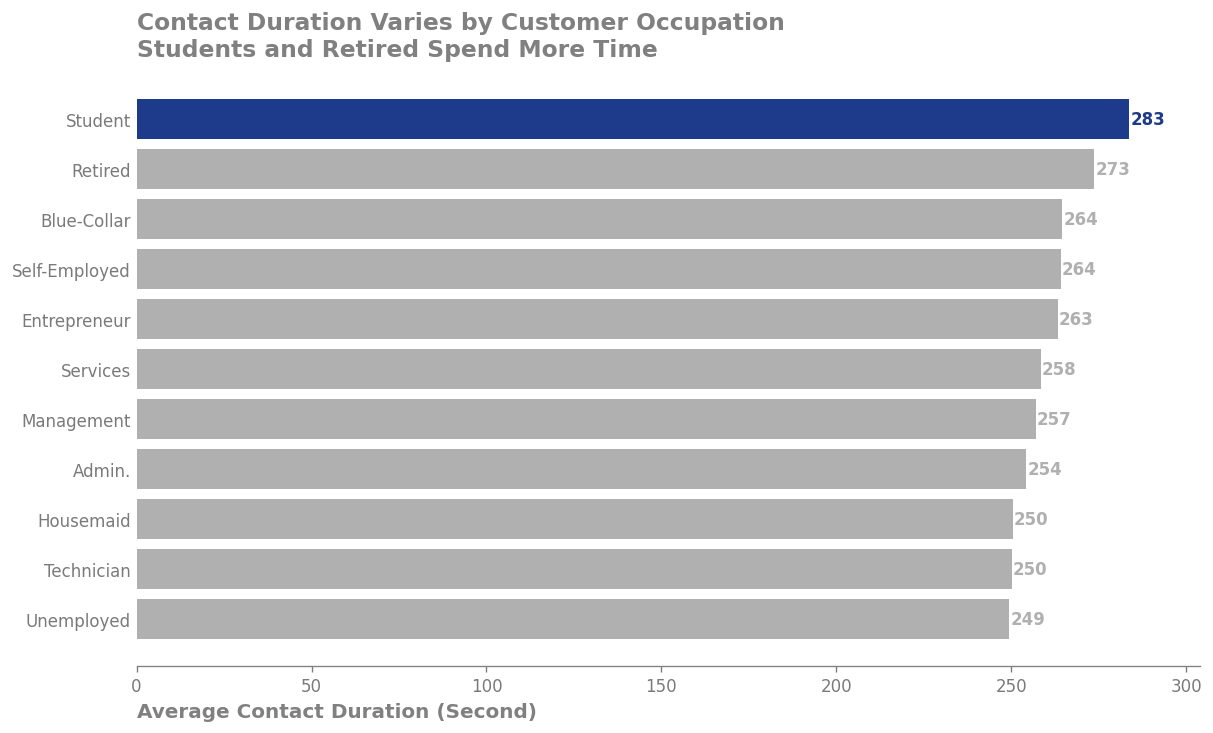

In [27]:
highlight_color = "#1E3A8A"   
base_color = "#B0B0B0"       

colors = [highlight_color] + [base_color] * (len(average_contact_duration_per_job) - 1)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.barh(
    average_contact_duration_per_job["job"] ,
    average_contact_duration_per_job["average_contact_duration"],
    color=colors
)

ax.invert_yaxis()

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines["bottom"].set_color("gray")

ax.set_title(
    "Contact Duration Varies by Customer Occupation\nStudents and Retired Spend More Time",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="gray",
    pad=10
)

ax.set_xlabel(
    "Average Contact Duration (Second)",
    loc="left",
    fontsize=12,
    fontweight="bold",
    color="gray",
)

max_x = int(np.ceil(average_contact_duration_per_job["average_contact_duration"].max() / 2) * 2)
ax.set_xlim(0, max_x+20)

for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = highlight_color if i == 0 else base_color

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_yticks(ticks=range(len(average_contact_duration_per_job["job"])),
              labels=[job.title() for job in average_contact_duration_per_job["job"]])

plt.savefig(FIGURES_DIR / "9.png")
plt.show()

This horizontal bar chart shows the average contact duration (in seconds) for different customer occupations, regardless of subscription status.

### Key insights:
- Students and retired individuals have the longest average contact duration (~283s and ~273s, respectively), which suggests that these groups either require more detailed conversations or are more engaged during calls.
- Other occupations like blue-collar, self-employed, and entrepreneurs exhibit moderate contact durations (~263–264s), indicating a consistent level of engagement.
- Occupations such as unemployed, technicians, and housemaids have slightly shorter contact times (~249–250s), which might reflect less availability or a more concise conversation style.

### Business implication:
- Targeting engagement strategies: For occupations with longer contact times, consider designing personalized campaigns or providing additional resources to maximize conversion rates.
- Efficiency improvement: For groups with shorter contact durations, explore optimized scripts or quick decision incentives to enhance engagement.


In [28]:
job_marital_status = (pd.crosstab(
    index=df_bank_marketing.query("job != 'unknown'")["job"],
    columns=df_bank_marketing.query("marital_status != 'unknown'")["marital_status"],
    values=df_bank_marketing.query("job != 'unknown'")["job"],
    aggfunc="count",
    normalize="index"
)
.mul(100)
.round(2)
)

job_marital_status

marital_status,divorced,married,single
job,,,
admin.,12.30,50.47,37.23
blue-collar,7.88,72.37,19.75
entrepreneur,12.32,73.71,13.97
housemaid,15.23,73.51,11.26
management,11.33,71.52,17.15
retired,20.29,74.29,5.42
self-employed,9.39,63.84,26.77
services,13.42,57.89,28.69
student,1.03,4.69,94.28


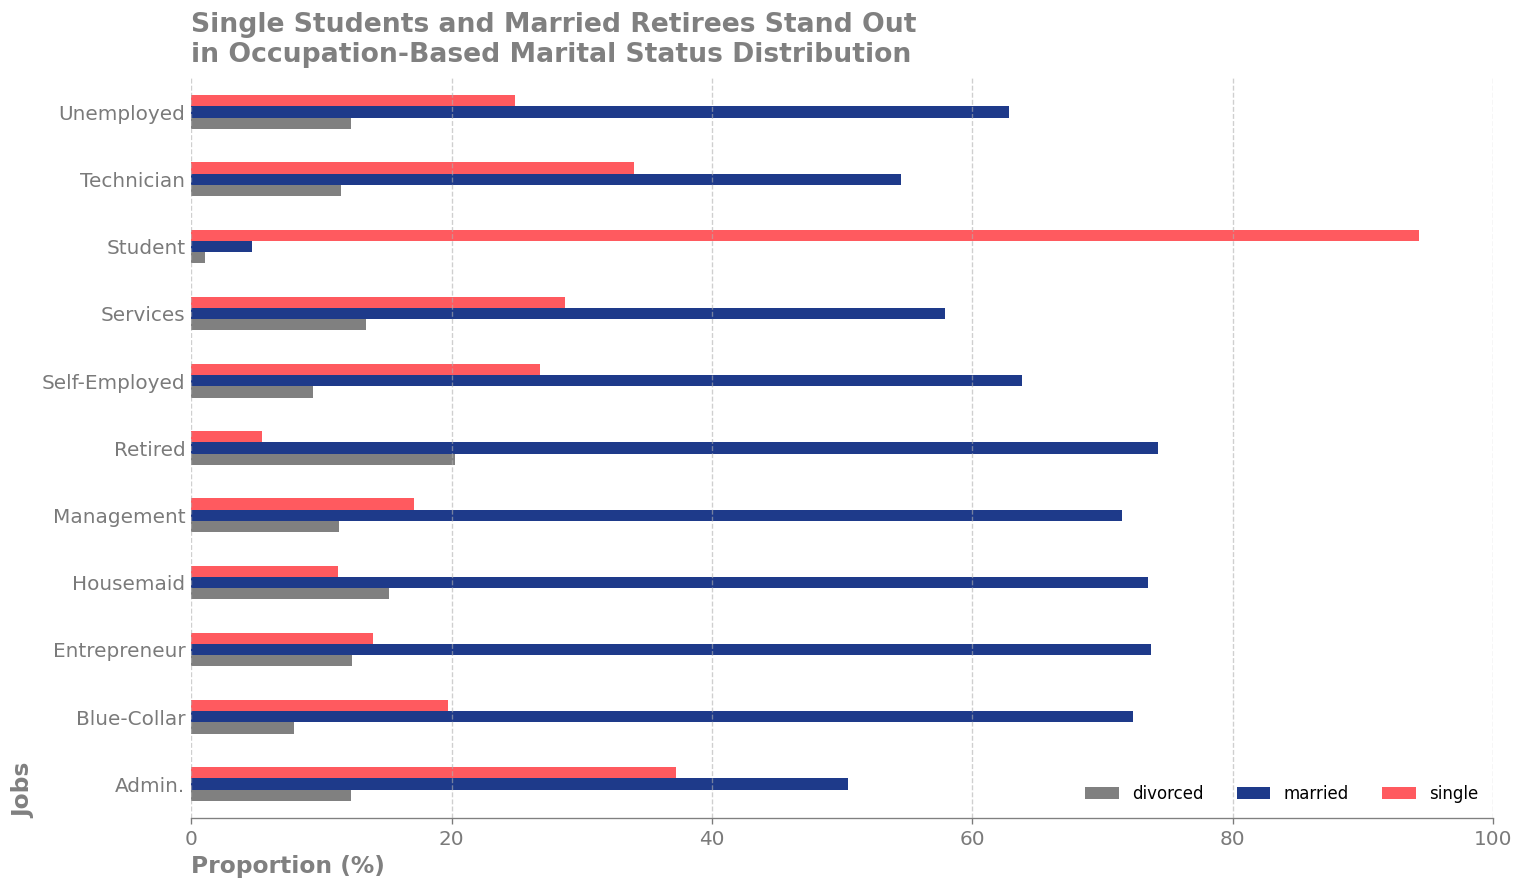

In [29]:
colors = ["#808080", "#1E3A8A", "#FF5A5F"]
job_marital_cmap = ListedColormap(colors=colors, name="job_marital_cmap")

fig, ax = plt.subplots(figsize=(14, 8))

job_marital_status.plot(kind="barh", cmap=job_marital_cmap, ax=ax)

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

ax.set_xlim(0, 100)

ax.set_title(
    "Single Students and Married Retirees Stand Out\nin Occupation-Based Marital Status Distribution",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16,
    pad=10

)
ax.set_xlabel("Proportion (%)", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Jobs", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="#7A7A7A", labelsize="large")
ax.tick_params(axis="y", length=0, colors="#7A7A7A", labelsize="large")

ax.set_yticks(ticks=range(len(job_marital_status.index)),
              labels=[job.title() for job in job_marital_status.index])


ax.grid(axis="x", linestyle="dashed", alpha=0.6)

plt.legend(ncol=5, loc="lower right", frameon=False)

plt.savefig(FIGURES_DIR / "10.png")
plt.show()

This horizontal stacked bar chart illustrates the proportion of marital status (single, married, divorced) within each occupation category for all customers.

### Key observations:
- Students are predominantly single, which aligns with expectations given their age group.
- Retired customers are overwhelmingly married, reflecting the demographic trend of older, married individuals.
- Other occupations, such as unemployed, blue-collar, and self-employed, show a higher proportion of married individuals, while singles and divorced proportions are moderate.
- Technicians and administrative roles exhibit a more balanced distribution between marital statuses.

### Business insights:
- Targeted marketing strategies: Campaigns could be personalized based on marital status in combination with occupation, e.g., promotions tailored for single students vs. married retirees.
- Engagement optimization: Knowing the marital composition can help design messaging that resonates with life-stage priorities of each occupational group.


### Subscription Rates Analysis

In [30]:
jobs_total = (
    df_bank_marketing.groupby("job")
    .agg(number = ("job" , "count"))
    .sort_values("number" , ascending=False)
    .reset_index()
)

jobs_total

,job,number
0,admin.,10422
1,blue-collar,9254
2,technician,6743
3,services,3969
4,management,2924
5,retired,1720
6,entrepreneur,1456
7,self-employed,1421
8,housemaid,1060
9,unemployed,1014


In [31]:
subscription_rate_by_job = (
    df_bank_marketing.query("job != 'unknown'")
    .groupby('job')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_job

,job,subscription_rate
0,student,31.43
1,retired,25.23
2,unemployed,14.20
3,admin.,12.97
4,management,11.22
5,technician,10.83
6,self-employed,10.49
7,housemaid,10.00
8,entrepreneur,8.52
9,services,8.14


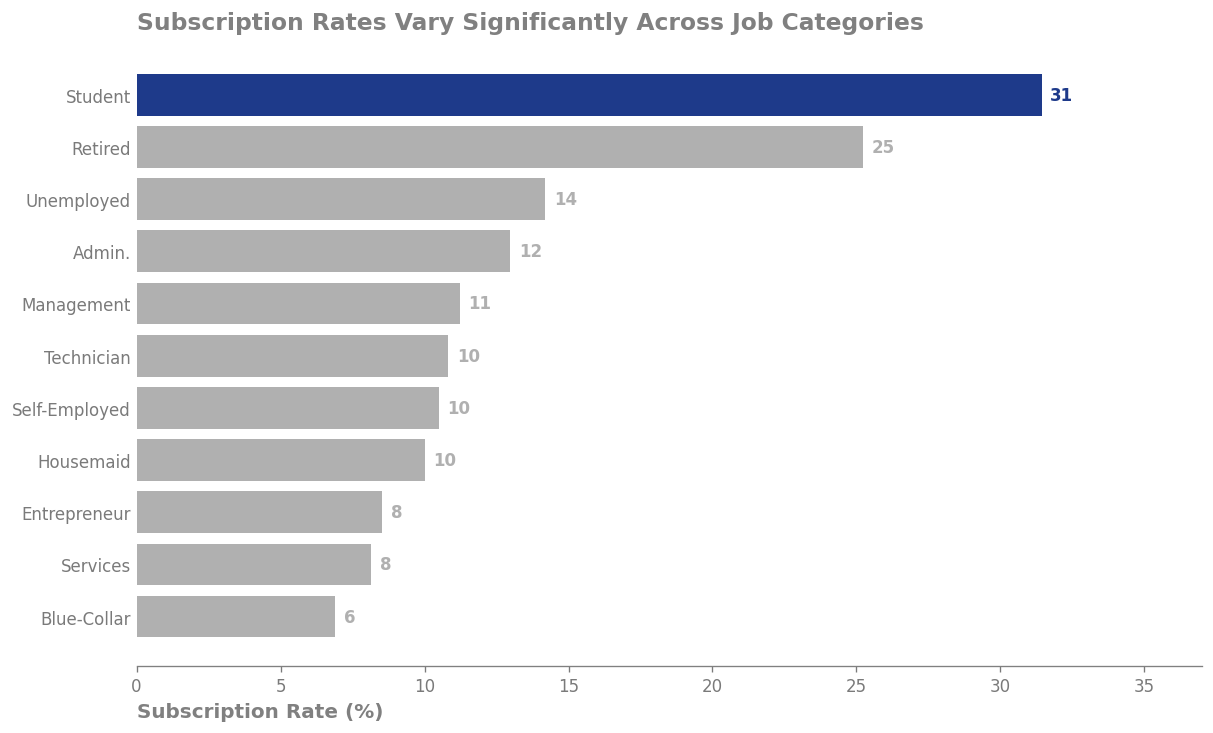

In [32]:
highlight_color = "#1E3A8A"   
base_color = "#B0B0B0"       

colors = [highlight_color] + [base_color] * (len(subscription_rate_by_job) - 1)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.barh(
    subscription_rate_by_job["job"] ,
    subscription_rate_by_job["subscription_rate"],
    color=colors
)

ax.invert_yaxis()

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines["bottom"].set_color("gray")

ax.set_title(
    "Subscription Rates Vary Significantly Across Job Categories",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="gray",
    pad=10
)

ax.set_xlabel(
    "Subscription Rate (%)",
    loc="left",
    fontsize=12,
    fontweight="bold",
    color="gray",
)

max_x = int(np.ceil(subscription_rate_by_job["subscription_rate"].max() / 2) * 2)
ax.set_xlim(0, max_x+5)

for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = highlight_color if i == 0 else base_color

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_yticks(ticks=range(len(subscription_rate_by_job["job"])),
              labels=[job.title() for job in subscription_rate_by_job["job"]])

plt.savefig(FIGURES_DIR / "11.png")
plt.show()

This horizontal bar chart highlights the subscription rates by customer occupation. 

### Key observations:
- Students and retired individuals have the highest subscription rates (31% and 25%, respectively), indicating these segments are more responsive to marketing efforts.
- Blue-collar, services, and entrepreneur categories show lower subscription rates (6–8%), suggesting potential for targeted engagement strategies.
- Understanding these patterns can help the bank prioritize marketing campaigns towards occupations with higher likelihood of subscription, while designing incentives for lower-performing segments.


In [33]:
educations_total = (
    df_bank_marketing.groupby("education_level")
    .agg(number = ("education_level" , "count"))
    .sort_values("number" , ascending=False)
    .reset_index()
)

educations_total

,education_level,number
0,university.degree,12168
1,high.school,9515
2,basic.9y,6045
3,professional.course,5243
4,basic.4y,4176
5,basic.6y,2292
6,unknown,1731
7,illiterate,18


In [34]:
subscription_rate_by_education = (
    df_bank_marketing.query("education_level != 'unknown'")
    .groupby('education_level')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_education

,education_level,subscription_rate
0,illiterate,22.22
1,university.degree,13.72
2,professional.course,11.35
3,high.school,10.84
4,basic.4y,10.25
5,basic.6y,8.20
6,basic.9y,7.82


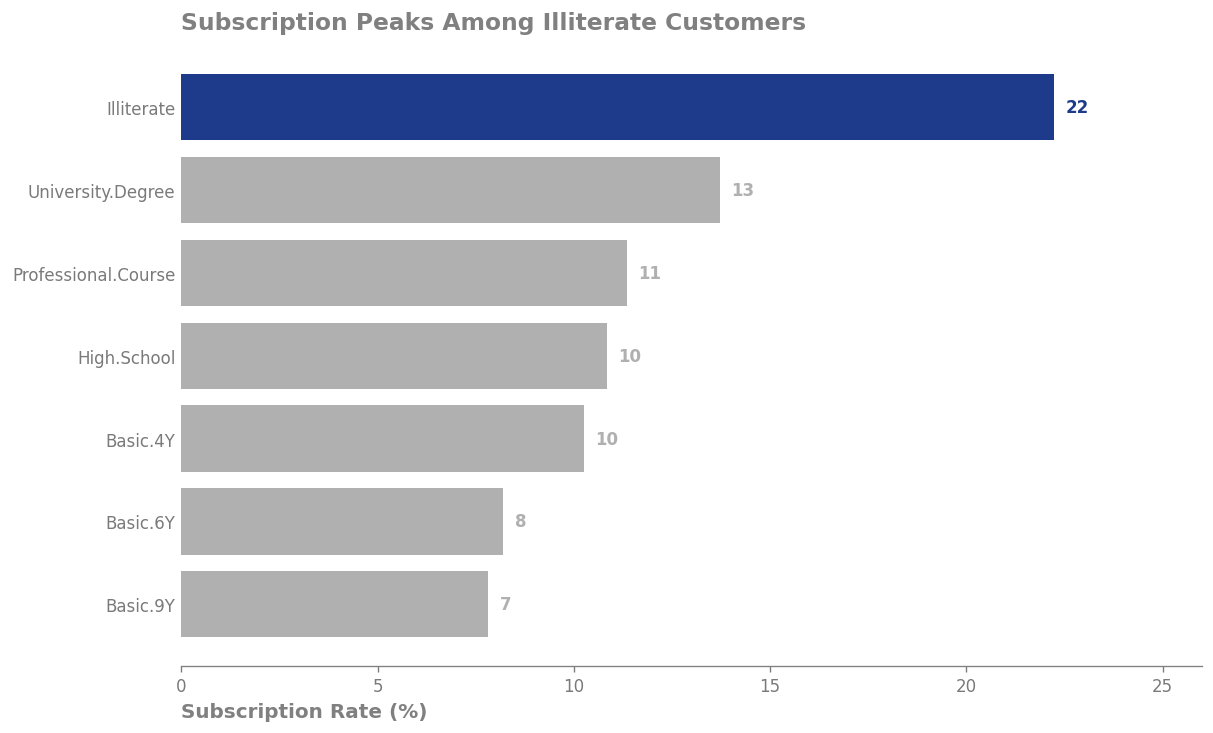

In [35]:
highlight_color = "#1E3A8A"   
base_color = "#B0B0B0"       

colors = [highlight_color] + [base_color] * (len(subscription_rate_by_education) - 1)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.barh(
    subscription_rate_by_education["education_level"] ,
    subscription_rate_by_education["subscription_rate"],
    color=colors
)

ax.invert_yaxis()

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines["bottom"].set_color("gray")

ax.set_title(
    "Subscription Peaks Among Illiterate Customers",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="gray",
    pad=10
)

ax.set_xlabel(
    "Subscription Rate (%)",
    loc="left",
    fontsize=12,
    fontweight="bold",
    color="gray",
)

max_x = int(np.ceil(subscription_rate_by_education["subscription_rate"].max() / 2) * 2)
ax.set_xlim(0, max_x+2)

for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = highlight_color if i == 0 else base_color

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_yticks(ticks=range(len(subscription_rate_by_education["education_level"])),
              labels=[job.title() for job in subscription_rate_by_education["education_level"]])

plt.savefig(FIGURES_DIR / "12.png")
plt.show()

This bar chart shows subscription rates by education levels. 

### Key insights:
- Surprisingly, illiterate customers exhibit the highest subscription rate (22%), indicating that marketing campaigns resonate strongly with this segment, possibly due to personalized phone outreach.
- Customers with higher education, such as university graduates and professional courses, show moderate subscription rates (11–13%), which may suggest less responsiveness  or higher selectivity.
- The bank can leverage this insight by designing tailored messaging for each education segment to improve conversion, particularly focusing on mid-education customers who might respond to targeted incentives.


In [36]:
marital_status_total = (
    df_bank_marketing.groupby("marital_status")
    .agg(number = ("marital_status" , "count"))
    .sort_values("number" , ascending=False)
    .reset_index()
)

marital_status_total

,marital_status,number
0,married,24928
1,single,11568
2,divorced,4612
3,unknown,80


In [37]:
subscription_rate_by_marital_status = (
    df_bank_marketing.query("marital_status != 'unknown'")
    .groupby('marital_status')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_marital_status

,marital_status,subscription_rate
0,single,14.00
1,divorced,10.32
2,married,10.16


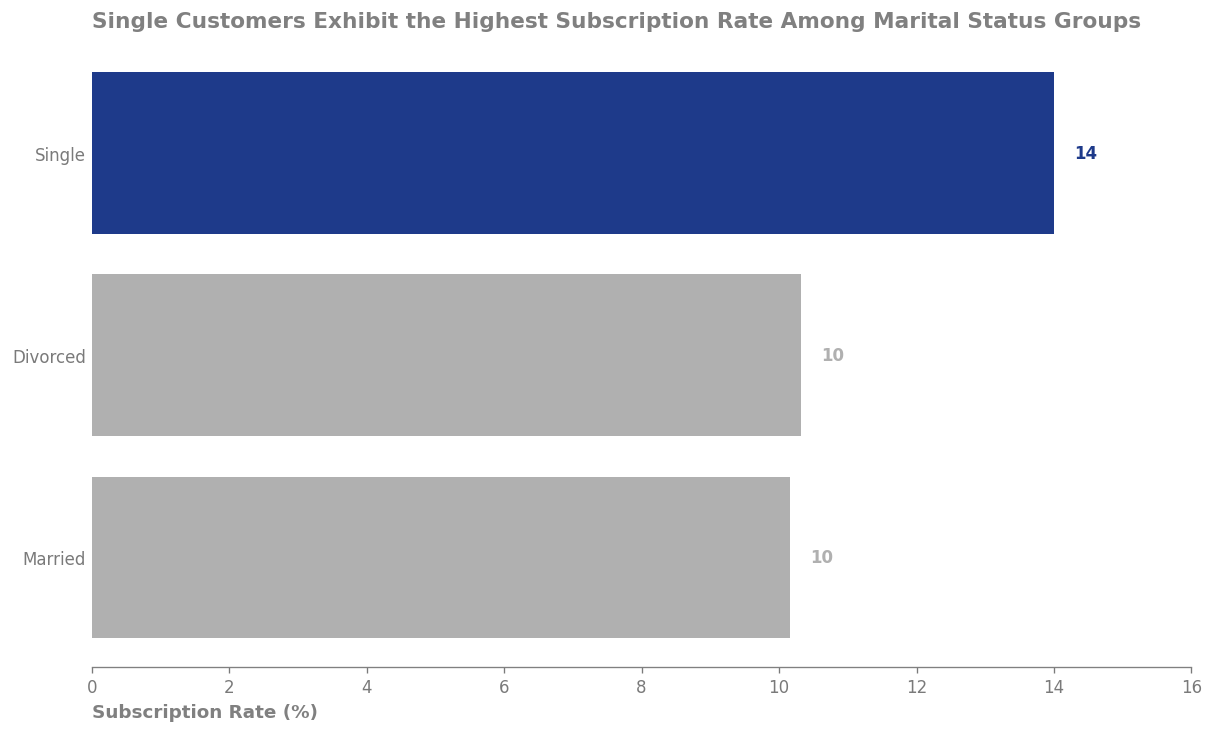

In [38]:
highlight_color = "#1E3A8A"   
base_color = "#B0B0B0"       

colors = [highlight_color] + [base_color] * (len(subscription_rate_by_marital_status) - 1)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.barh(
    subscription_rate_by_marital_status["marital_status"] ,
    subscription_rate_by_marital_status["subscription_rate"],
    color=colors
)

ax.invert_yaxis()

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines["bottom"].set_color("gray")

ax.set_title(
    "Single Customers Exhibit the Highest Subscription Rate Among Marital Status Groups",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="gray",
    pad=10
)

ax.set_xlabel(
    "Subscription Rate (%)",
    loc="left",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

max_x = int(np.ceil(subscription_rate_by_marital_status["subscription_rate"].max() / 2) * 2)
ax.set_xlim(0, max_x+2)

for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = highlight_color if i == 0 else base_color

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_yticks(ticks=range(len(subscription_rate_by_marital_status["marital_status"])),
              labels=[job.title() for job in subscription_rate_by_marital_status["marital_status"]])

plt.savefig(FIGURES_DIR / "13.png")
plt.show()

### Key takeaways:

- Single customers lead with a 14% subscription rate, noticeably higher than married and divorced individuals (~10%).
- This suggests that single individuals may respond more positively to phone-based marketing campaigns, possibly due to higher engagement or availability.
- Marketing teams could leverage this insight by designing specific campaigns targeting single customers to maximize conversions, while exploring ways to improve engagement for married and divorced segments.


In [39]:
subscription_rate_by_housing = (
    df_bank_marketing.query("has_housing_loan != 'unknown'")
    .groupby('has_housing_loan')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_housing

,has_housing_loan,subscription_rate
0,yes,11.62
1,no,10.88


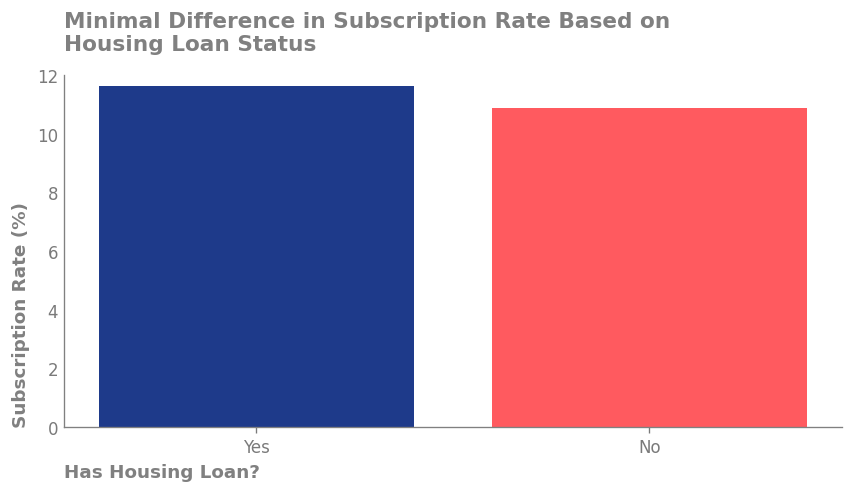

In [40]:
highlight_color = "#1E3A8A"   
base_color = "#FF5A5F"       

colors = [highlight_color] + [base_color] * (len(subscription_rate_by_housing) - 1)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

bars = ax.bar(
    subscription_rate_by_housing["has_housing_loan"] ,
    subscription_rate_by_housing["subscription_rate"],
    color=colors
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("gray")

max_y = int(np.ceil(subscription_rate_by_housing["subscription_rate"].max() / 2) * 2)
ax.set_ylim(0, max_y)

ax.set_title(
    "Minimal Difference in Subscription Rate Based on\nHousing Loan Status",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="gray",
    pad=15
)

ax.set_xlabel(
    "Has Housing Loan?",
    loc="left",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

ax.set_ylabel(
    "Subscription Rate (%)",
    loc="bottom",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_xticks(ticks=range(len(subscription_rate_by_housing["has_housing_loan"])),
              labels=[job.title() for job in subscription_rate_by_housing["has_housing_loan"]])

plt.savefig(FIGURES_DIR / "14.png")
plt.show()

A comparison of subscription rates for customers with and without a housing loan shows very little difference:

- With housing loan: 11.62%
- Without housing loan: 10.88%

Insight: Housing loan ownership does not significantly influence subscription behavior, suggesting that marketing strategies need not prioritize or segment based on this factor


In [41]:
subscription_rate_by_personal_loan = (
    df_bank_marketing.query("has_personal_loan != 'unknown'")
    .groupby('has_personal_loan')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_personal_loan

,has_personal_loan,subscription_rate
0,no,11.34
1,yes,10.93


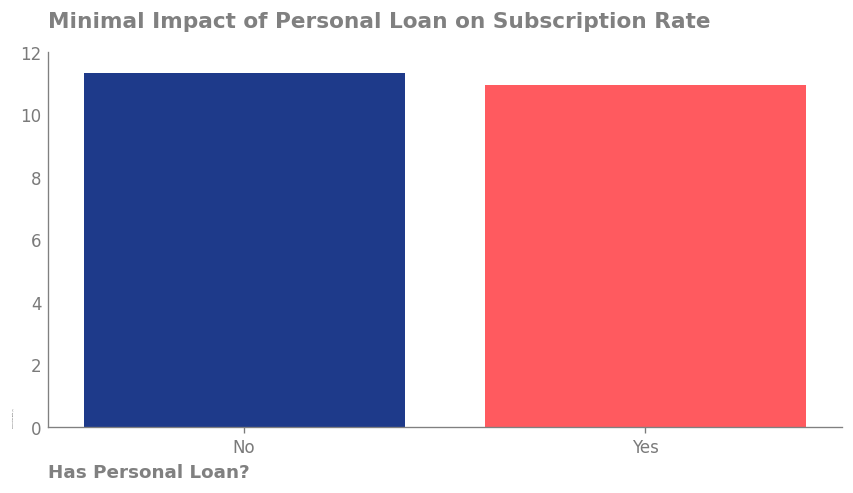

In [42]:
highlight_color = "#1E3A8A"   
base_color = "#FF5A5F"       

colors = [highlight_color] + [base_color] * (len(subscription_rate_by_personal_loan) - 1)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

bars = ax.bar(
    subscription_rate_by_personal_loan["has_personal_loan"] ,
    subscription_rate_by_personal_loan["subscription_rate"],
    color=colors
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("gray")

max_y = int(np.ceil(subscription_rate_by_personal_loan["subscription_rate"].max() / 2) * 2)
ax.set_ylim(0, max_y)

ax.set_title(
    "Minimal Impact of Personal Loan on Subscription Rate",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="gray",
    pad=15
)

ax.set_xlabel(
    "Has Personal Loan?",
    loc="left",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

ax.set_ylabel(
    "Subscription Rate (%)",
    loc="bottom",
    fontsize=1,
    fontweight="bold",
    color="gray",
)

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_xticks(ticks=range(len(subscription_rate_by_personal_loan["has_personal_loan"])),
              labels=[job.title() for job in subscription_rate_by_personal_loan["has_personal_loan"]])

plt.savefig(FIGURES_DIR / "15.png")
plt.show()

Subscription rates for customers with and without a personal loan show negligible differences:

- With personal loan: 10.93%
- Without personal loan: 11.34%

Insight: Personal loan ownership has little to no effect on subscription behavior. From a business perspective, this suggests that targeting or segmenting customers based on personal loan status may not provide significant marketing advantages. Focus can be placed on more impactful features.


In [43]:
df_bank_marketing['contact_method'].value_counts()

contact_method
cellular     26144
telephone    15044
Name: count, dtype: int64

In [44]:
subscription_rate_by_contact_method = (
    df_bank_marketing.groupby('contact_method')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('subscription_rate', ascending=False)
    .reset_index()
)

subscription_rate_by_contact_method

,contact_method,subscription_rate
0,cellular,14.74
1,telephone,5.23


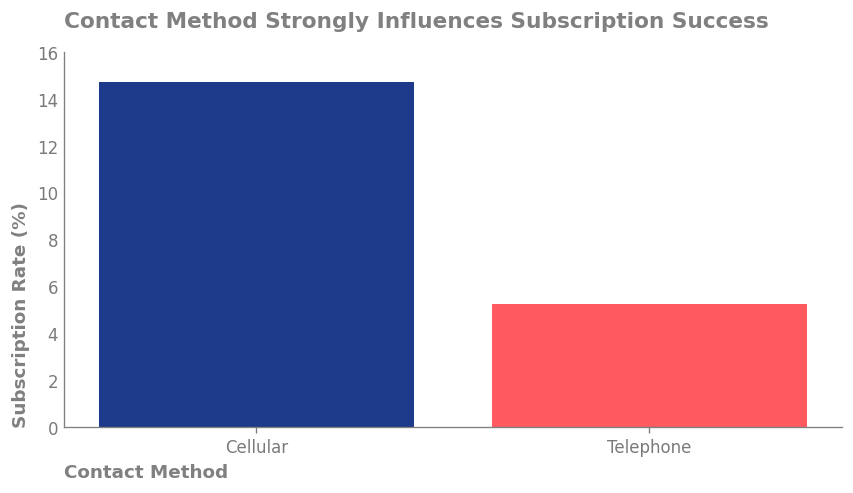

In [45]:
highlight_color = "#1E3A8A"   
base_color = "#FF5A5F"       

colors = [highlight_color] + [base_color] * (len(subscription_rate_by_contact_method) - 1)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

bars = ax.bar(
    subscription_rate_by_contact_method["contact_method"] ,
    subscription_rate_by_contact_method["subscription_rate"],
    color=colors
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("gray")

max_y = int(np.ceil(subscription_rate_by_contact_method["subscription_rate"].max() / 2) * 2)
ax.set_ylim(0, max_y)

ax.set_title(
    "Contact Method Strongly Influences Subscription Success",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="gray",
    pad=15
)

ax.set_xlabel(
    "Contact Method",
    loc="left",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

ax.set_ylabel(
    "Subscription Rate (%)",
    loc="bottom",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_xticks(ticks=range(len(subscription_rate_by_contact_method["contact_method"])),
              labels=[job.title() for job in subscription_rate_by_contact_method["contact_method"]])

plt.savefig(FIGURES_DIR / "16.png")
plt.show()

Subscription rate varies significantly based on the method of contact:

- Cellular contact: 14.74%
- Landline contact: 5.23%

Business Insight: The data shows that mobile contacts are nearly three times more effective than landlines for subscription conversions. For marketing strategy, this indicates that allocating more resources to cellular outreach could substantially improve campaign efficiency and ROI.


In [46]:
subscription_rate_by_job_contact = (pd.crosstab(
    index=df_bank_marketing.query("job != 'unknown'")["job"],
    columns=df_bank_marketing["contact_method"],
    values=df_bank_marketing["subscribed"],
    aggfunc="mean",
)
.mul(100)
.round(2)
)

subscription_rate_by_job_contact

contact_method,cellular,telephone
job,,
admin.,16.26,5.86
blue-collar,9.02,4.30
entrepreneur,10.41,5.82
housemaid,12.97,5.48
management,14.41,5.28
retired,31.60,9.20
self-employed,14.45,3.79
services,10.99,4.16
student,36.36,15.20


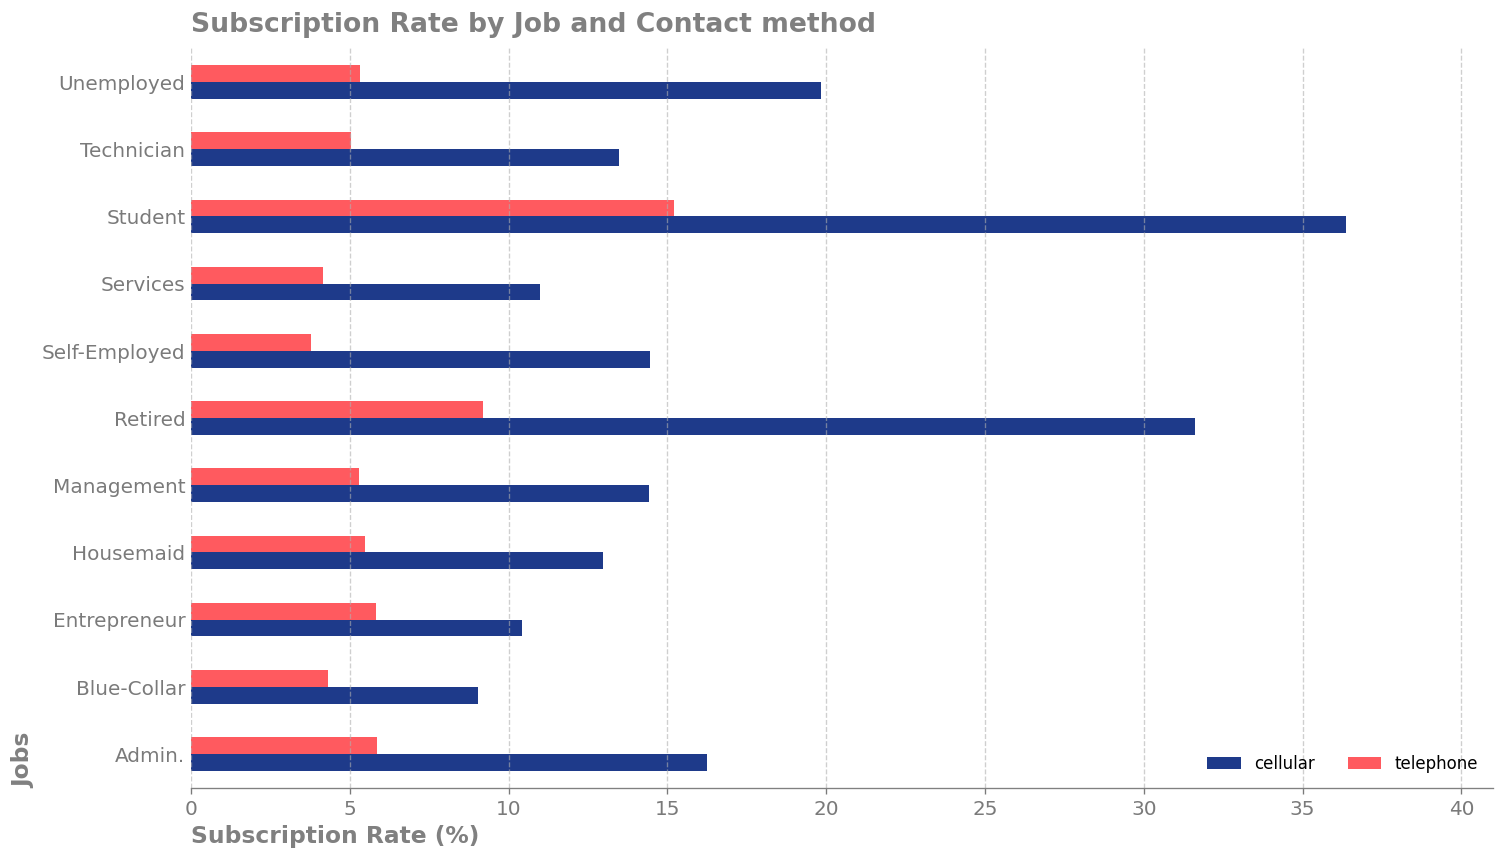

In [47]:
colors = ["#1E3A8A", "#FF5A5F"]
job_contact_cmap = ListedColormap(colors=colors, name="job_contact_cmap")

fig, ax = plt.subplots(figsize=(14, 8))

subscription_rate_by_job_contact.plot(kind="barh", cmap=job_contact_cmap, ax=ax)

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")

max_x = int(np.ceil(subscription_rate_by_job_contact.values.max() / 2) * 2.2)
ax.set_xlim(0, max_x)

ax.set_title(
    "Subscription Rate by Job and Contact method",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16,
    pad=10

)
ax.set_xlabel("Subscription Rate (%)", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Jobs", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="#7A7A7A", labelsize="large")
ax.tick_params(axis="y", length=0, colors="#7A7A7A", labelsize="large")

ax.set_yticks(ticks=range(len(subscription_rate_by_job_contact.index)),
              labels=[job.title() for job in subscription_rate_by_job_contact.index])


ax.grid(axis="x", linestyle="dashed", alpha=0.6)

plt.legend(ncol=5, loc="lower right", frameon=False)

plt.savefig(FIGURES_DIR / "17.png")
plt.show()

In [48]:
subscription_rate_by_campaign_contacts = (
    df_bank_marketing.groupby('campaign_contacts')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .reset_index()
)

subscription_rate_by_campaign_contacts.head(10)

,campaign_contacts,subscription_rate
0,1,13.04
1,2,11.46
2,3,10.75
3,4,9.39
4,5,7.50
5,6,7.66
6,7,6.04
7,8,4.25
8,9,6.01
9,10,5.33


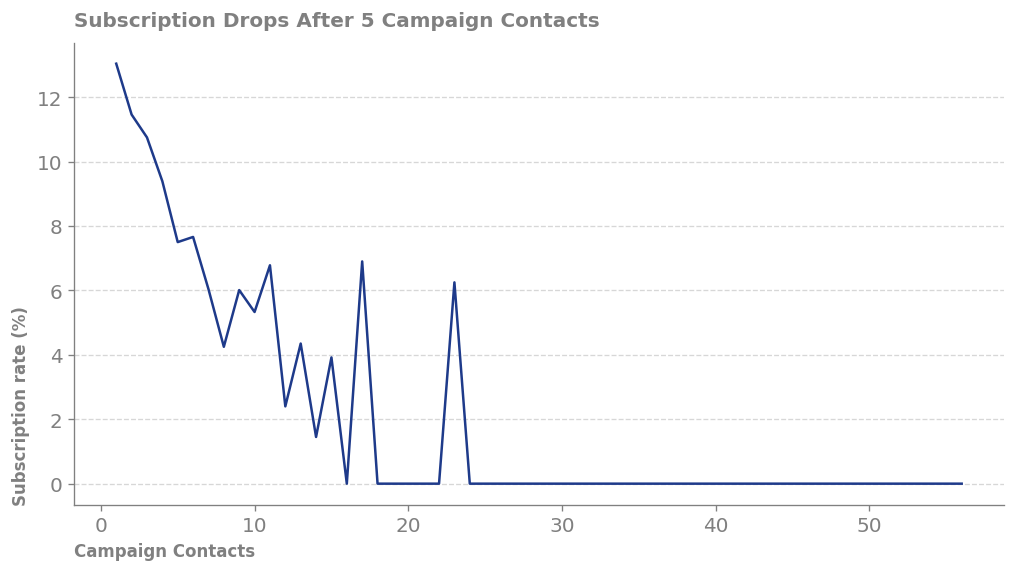

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.lineplot(
    data=subscription_rate_by_campaign_contacts,
    x="campaign_contacts",
    y="subscription_rate",
    color='#1E3A8A'
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Subscription Drops After 5 Campaign Contacts",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,
    pad=10

)
ax.set_xlabel("Campaign Contacts"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax.set_ylabel("Subscription rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.savefig(FIGURES_DIR / "18.png")
plt.show()

### Effect of Campaign Frequency on Subscription Success

- Trend: Subscription rate decreases as the number of contacts increases.

### Key Observations:

- Customers contacted fewer than 5 times achieve the highest success rate (~12–13%).
- After 10 contacts, the success rate drops below 5%, and additional contacts provide minimal incremental effect.

### Business Insight:
- Optimal contact threshold: More than 5 contacts per campaign yields diminishing returns.
- Resource efficiency: Marketing budget and team effort are better focused on new or less-contacted prospects.
- Avoid over-contacting: Excessive calls may lead to customer fatigue and reduce overall campaign ROI.


### Last Contact Duration Distribution

In [50]:
df_bank_marketing['contact_duration'].describe()

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: contact_duration, dtype: float64

In [51]:
df_bank_marketing.query("contact_duration == 0").filter(['contact_duration', 'subscribed'])

,contact_duration,subscribed
6251,0,0
23031,0,0
28063,0,0
33015,0,0


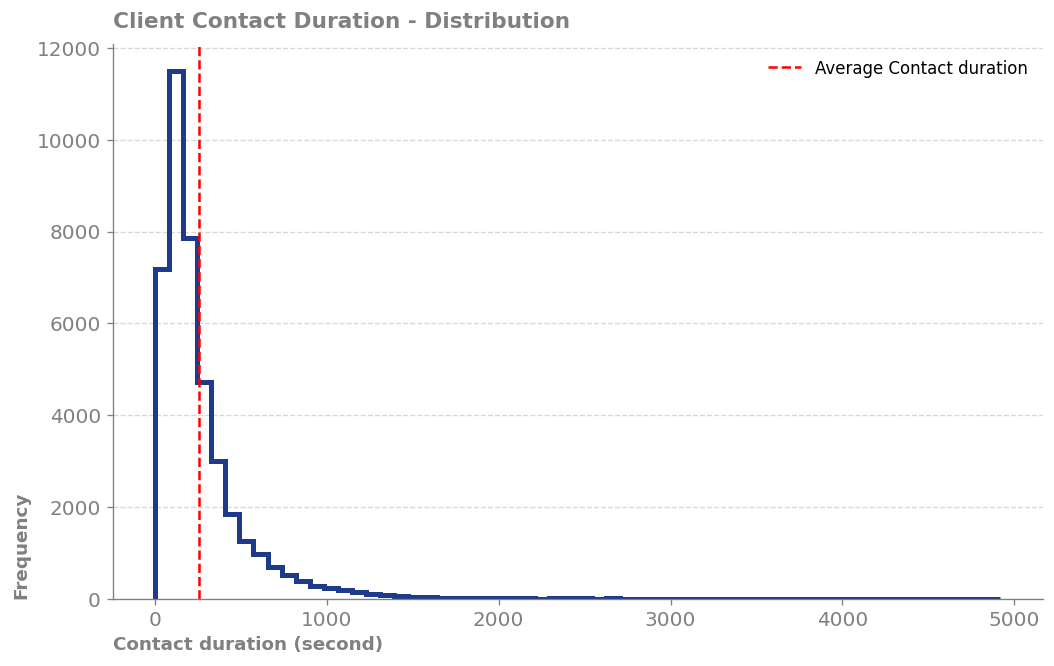

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(df_bank_marketing['contact_duration'], 
         bins=60, 
         color='#1E3A8A',    
         histtype="step",
         lw=3
)

plt.axvline(df_bank_marketing['contact_duration'].mean(),
            linestyle='--', linewidth=1.5, color='red', label='Average Contact duration')

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

plt.title(
    "Client Contact Duration - Distribution",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=13,
    pad=10
)
plt.xlabel("Contact duration (second)", 
           loc="left", 
           weight="bold", 
           color="gray", 
           fontsize=11)
plt.ylabel("Frequency", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=11)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.legend(frameon=False)

plt.savefig(FIGURES_DIR / "19.png")
plt.show()

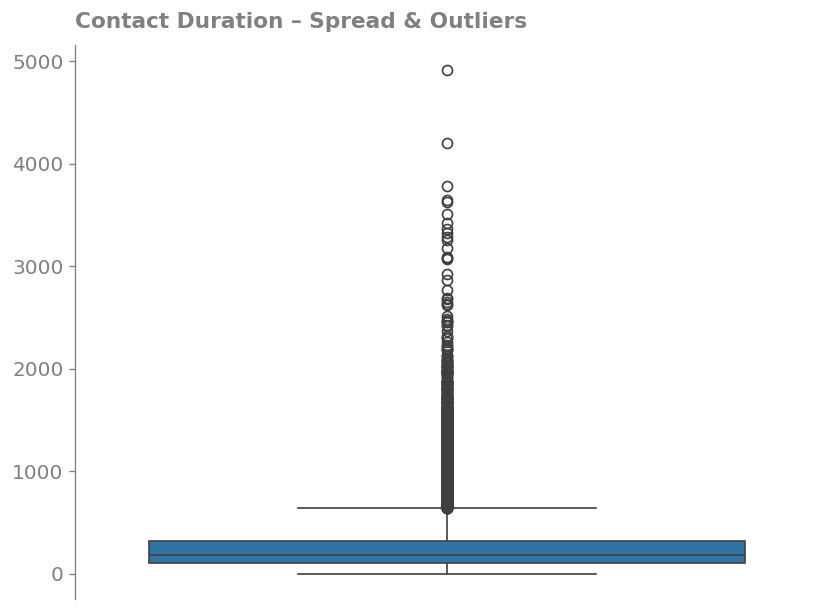

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(y='contact_duration', 
            data=df_bank_marketing
            )

ax.spines[["right", "top", "bottom"]].set_visible(False)
ax.spines[["left"]].set_color("gray")

plt.title(
    "Contact Duration – Spread & Outliers",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=13,
    pad=10
)
plt.ylabel("")

ax.tick_params(axis="x", length=0, colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.savefig(FIGURES_DIR / "20.png")
plt.show()

### Data Insight:

- Most calls are short, but there are several extremely long calls.
- Median is lower than mean, highlighting that most contacts are short.
- Circles above the box represent long calls, which are real events and not removed.
	
### Business Implication:

- Short calls represent typical customer behavior and can inform campaign timing and efficiency.
- Long calls may indicate high interest or complex needs and could identify high-value customers.

### Modeling Implication:

- These long-duration calls influence machine learning models and are kept to improve subscription prediction accuracy.

### Recency of Last Contact (Previous Campaign)


In [54]:
previously_contacted_proportion = (df_bank_marketing.query("days_since_last_contact != 999").shape[0]
                        /df_bank_marketing.shape[0]
).__mul__(100).__round__(2)

previously_contacted_proportion

3.68

In [55]:
previously_contacted_days = (
    df_bank_marketing.query("days_since_last_contact != 999")
)

previously_contacted_days

,age,job,marital_status,education_level,has_default,has_housing_loan,has_personal_loan,contact_method,last_contact_month,last_contact_day_of_week,contact_duration,campaign_contacts,days_since_last_contact,previous_campaign_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor3m_rate,nr_employed,subscribed,age_group
24108,37,admin.,married,university.degree,no,yes,no,telephone,nov,wed,119,1,6,1,success,-0.1,93.200,-42.0,4.286,5195.8,0,30-40
24264,48,management,married,university.degree,no,yes,no,cellular,nov,mon,112,1,4,1,success,-0.1,93.200,-42.0,4.191,5195.8,0,40-50
24279,42,technician,married,professional.course,unknown,yes,no,cellular,nov,mon,94,1,4,1,success,-0.1,93.200,-42.0,4.191,5195.8,0,40-50
24397,50,entrepreneur,married,university.degree,unknown,yes,no,cellular,nov,mon,77,1,3,1,success,-0.1,93.200,-42.0,4.191,5195.8,0,50-60
24482,36,self-employed,single,university.degree,no,yes,no,cellular,nov,mon,200,2,4,1,success,-0.1,93.200,-42.0,4.191,5195.8,0,30-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41163,35,technician,divorced,basic.4y,no,yes,no,cellular,nov,tue,385,3,4,2,success,-1.1,94.767,-50.8,1.035,4963.6,1,30-40
41164,54,admin.,married,professional.course,no,no,no,cellular,nov,tue,1868,2,10,1,success,-1.1,94.767,-50.8,1.035,4963.6,1,50-60
41174,62,retired,married,university.degree,no,yes,no,cellular,nov,thu,208,1,1,6,success,-1.1,94.767,-50.8,1.031,4963.6,1,60+
41178,62,retired,married,university.degree,no,no,no,cellular,nov,thu,483,2,6,3,success,-1.1,94.767,-50.8,1.031,4963.6,1,60+


In [56]:
previously_contacted_days['days_since_last_contact'].describe()

count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: days_since_last_contact, dtype: float64

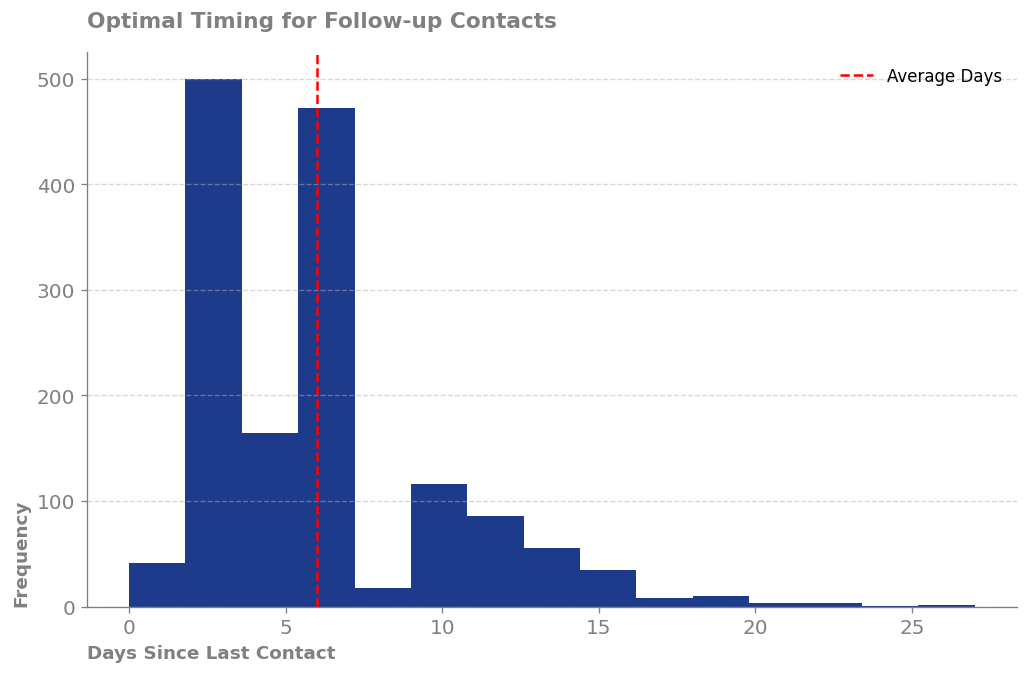

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(previously_contacted_days['days_since_last_contact'], 
         bins=15, 
         color='#1E3A8A')

plt.axvline(previously_contacted_days['days_since_last_contact'].mean(),
            linestyle='--', linewidth=1.5, color='red', label='Average Days')

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

plt.title(
    "Optimal Timing for Follow-up Contacts",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=13,
    pad=15
)
plt.xlabel("Days Since Last Contact", 
           loc="left", 
           weight="bold", 
           color="gray", 
           fontsize=11)
plt.ylabel("Frequency", 
           loc="bottom", 
           weight="bold", 
           color="gray", 
           fontsize=11)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.legend(frameon=False)

plt.savefig(FIGURES_DIR / "21 .png")
plt.show()

### Observations:

- The histogram shows the distribution of days since the last campaign contact, excluding customers who have never been contacted before.
- Most contacts occur within 5–6 days after the previous campaign (marked by the red dashed line for the average).
- There is a smaller group of customers contacted after 10+ days, but these are much less frequent.
- The distribution is right-skewed, indicating that a majority of follow-ups happen relatively quickly, while a few contacts are delayed significantly.

### Business Insight:
- Timely follow-ups: The majority of customers are reached within a week, which seems to be an effective interval.
- Strategic targeting: Customers contacted after longer intervals may represent a secondary or low-priority segment.

Note:

- Outliers (long intervals) are not removed, as they reflect real-world delays and are important for modeling and understanding campaign timing effects.


In [58]:
subscription_by_days_since_last_contact = (
    previously_contacted_days.groupby('days_since_last_contact')
    .agg(subscription_rate=('subscribed','mean'))
    .mul(100)
    .round(2)
    .sort_values('days_since_last_contact')
    .reset_index()
)

subscription_by_days_since_last_contact

,days_since_last_contact,subscription_rate
0,0,66.67
1,1,30.77
2,2,60.66
3,3,67.88
4,4,53.39
5,5,63.04
6,6,70.15
7,7,66.67
8,8,66.67
9,9,54.69


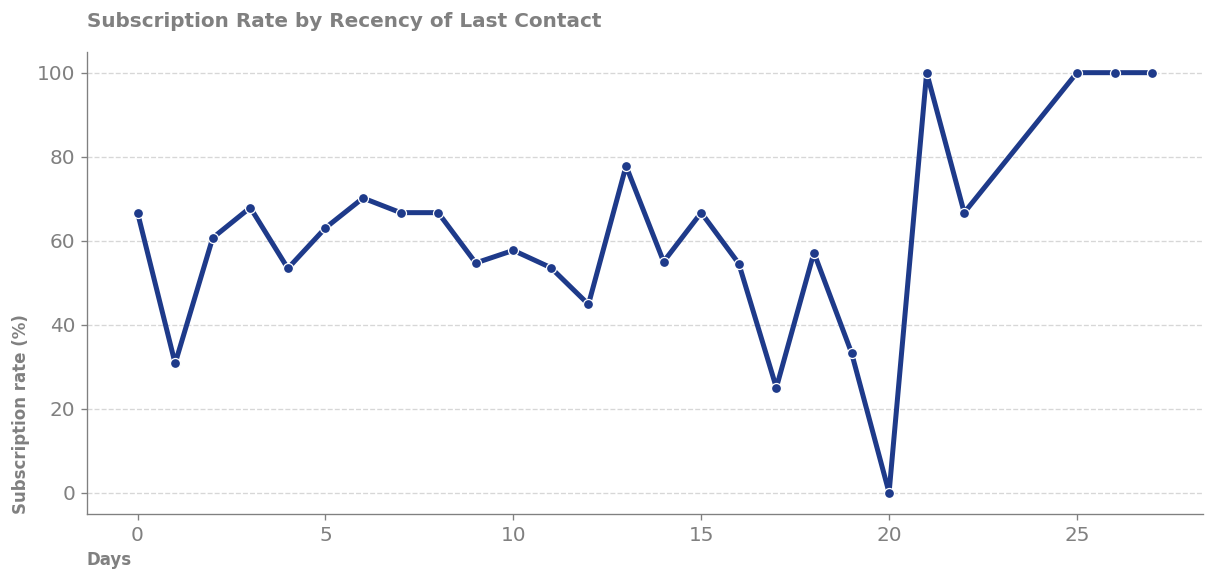

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))

ax = sns.lineplot(
    data=subscription_by_days_since_last_contact,
    x="days_since_last_contact",
    y="subscription_rate",
    marker="o",
    color='#1E3A8A',
    lw=3
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Subscription Rate by Recency of Last Contact",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,
    pad=15
)
ax.set_xlabel("Days"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax.set_ylabel("Subscription rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.savefig(FIGURES_DIR / "22.png")
plt.show()

### Observations:

- This line chart shows the subscription rate based on the number of days since the last campaign contact, considering only customers who had a previous contact.
- The subscription rate fluctuates across days, with higher success observed in the first few days after contact.
- After ~10–15 days, the rate shows variability but generally tends to decrease, indicating that more recent contacts are more effective.
- There are a few spikes for longer intervals, but these are likely due to low sample sizes in those bins.

### Business Insight:
- Recency matters: Customers contacted sooner after the previous campaign are more likely to subscribe.
- Target follow-ups: Focus marketing efforts on recently engaged customers for higher conversion rates.
- Modeling feature: Days since last contact is a key predictive feature for subscription likelihood.


In [60]:
previously_contacted_days.query("20 < days_since_last_contact")

,age,job,marital_status,education_level,has_default,has_housing_loan,has_personal_loan,contact_method,last_contact_month,last_contact_day_of_week,contact_duration,campaign_contacts,days_since_last_contact,previous_campaign_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor3m_rate,nr_employed,subscribed,age_group
39135,66,retired,married,professional.course,no,no,yes,cellular,mar,tue,525,1,21,2,failure,-1.8,93.369,-34.8,0.655,5008.7,1,60+
39883,28,management,single,university.degree,no,yes,no,cellular,jun,thu,383,1,22,1,success,-1.7,94.055,-39.8,0.729,4991.6,1,18-30
40234,60,admin.,married,basic.9y,no,no,no,cellular,jul,thu,174,2,25,2,failure,-1.7,94.215,-40.3,0.884,4991.6,1,60+
40243,24,technician,married,professional.course,no,no,no,cellular,jul,fri,192,4,26,1,success,-1.7,94.215,-40.3,0.885,4991.6,1,18-30
40489,30,admin.,single,high.school,no,no,no,telephone,aug,thu,18,1,22,1,success,-1.7,94.027,-38.3,0.899,4991.6,0,30-40
40668,38,technician,single,professional.course,no,yes,no,cellular,sep,thu,284,3,22,1,success,-1.1,94.199,-37.5,0.879,4963.6,1,30-40
40874,41,technician,married,professional.course,no,no,no,cellular,oct,wed,391,2,27,1,success,-1.1,94.601,-49.5,0.959,4963.6,1,40-50
41126,61,admin.,married,high.school,no,yes,no,cellular,nov,wed,300,1,21,5,failure,-1.1,94.767,-50.8,1.044,4963.6,1,60+


### Previous Campaign Success Analysis 

In [61]:
df_bank_marketing['previous_campaign_contacts'].value_counts()

previous_campaign_contacts
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

In [62]:
prev_campaign_contacts = (
    df_bank_marketing.filter(['previous_campaign_contacts', 'previous_campaign_outcome'])
    .query("previous_campaign_contacts > 0")
)

prev_campaign_contacts['previous_campaign_outcome'] = (
    prev_campaign_contacts['previous_campaign_outcome']
    .map({'failure': 0, 'success': 1})
)

prev_campaign_contacts

,previous_campaign_contacts,previous_campaign_outcome
24013,1,0
24019,1,0
24076,1,0
24102,1,0
24108,1,1
...,...,...
41174,6,1
41175,2,0
41178,3,1
41182,1,1


In [63]:
prev_campaign_success_rate = (
    prev_campaign_contacts['previous_campaign_outcome']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame()
    .reset_index()
)

prev_campaign_success_rate

,previous_campaign_outcome,proportion
0,0,75.59
1,1,24.41


In [64]:
prev_campaign_success_by_contacts = (
    prev_campaign_contacts.groupby('previous_campaign_contacts')
    .agg(success_rate=('previous_campaign_outcome','mean'))
    .mul(100)
    .round(2)
    .reset_index()
)

prev_campaign_success_by_contacts

,previous_campaign_contacts,success_rate
0,1,18.97
1,2,42.44
2,3,59.26
3,4,57.14
4,5,83.33
5,6,80.00
6,7,100.00


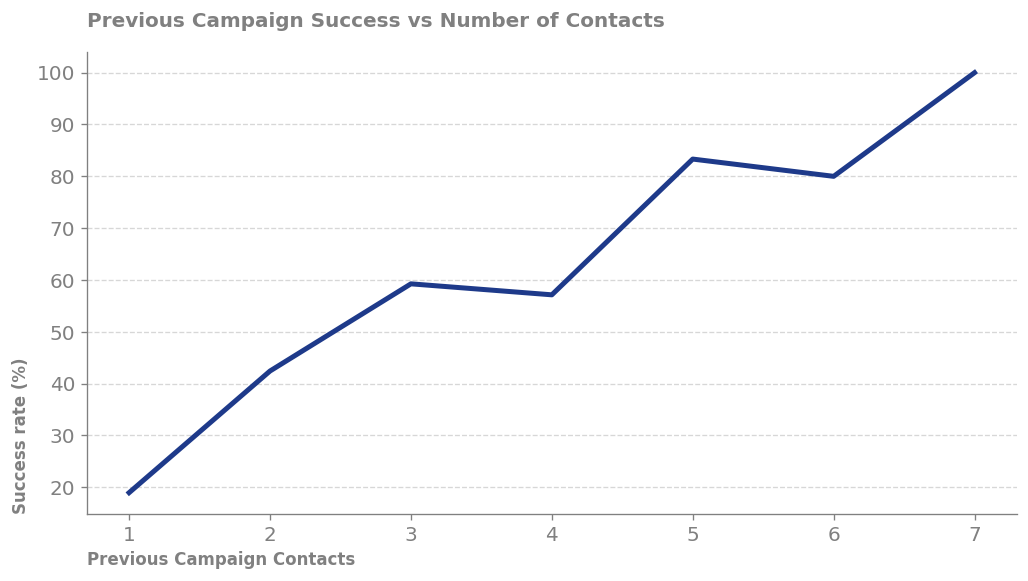

In [65]:
fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.lineplot(
    data=prev_campaign_success_by_contacts,
    x="previous_campaign_contacts",
    y="success_rate",
    color='#1E3A8A',
    lw=3
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Previous Campaign Success vs Number of Contacts",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,
    pad=15
)
ax.set_xlabel("Previous Campaign Contacts"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax.set_ylabel("Success rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.savefig(FIGURES_DIR / "23.png")
plt.show()

The line chart shows the success rate of previous campaigns based on the number of contacts per campaign.

### Insights:

- Trend: More contacts in the previous campaign are associated with a higher success rate, showing a clear positive relationship.
- Business Insight: Customers with more frequent past contacts tend to subscribe more, suggesting that past engagement intensity is a strong predictor of future campaign success.


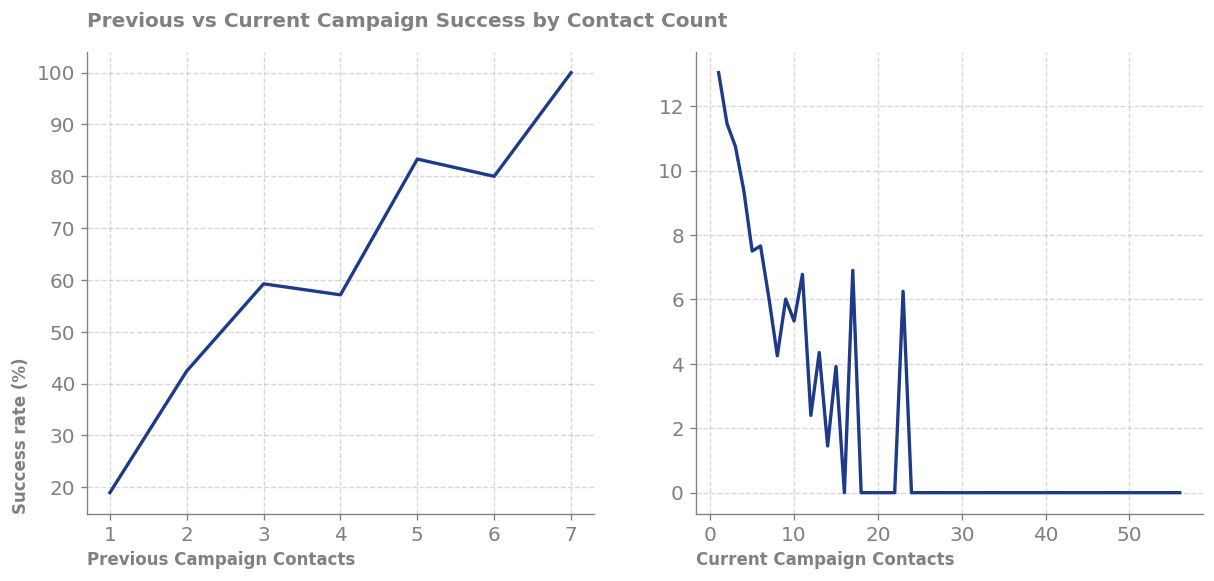

In [66]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

sns.lineplot(
    data=prev_campaign_success_by_contacts,
    x="previous_campaign_contacts",
    y="success_rate",
    color='#1E3A8A',
    lw=2,
    ax=ax[0]
)

sns.lineplot(
    data=subscription_rate_by_campaign_contacts,
    x="campaign_contacts",
    y="subscription_rate",
    color='#1E3A8A',
    lw=2,
    ax=ax[1]
)

ax[0].spines[["right", "top"]].set_visible(False)
ax[0].spines[["left", "bottom"]].set_color("gray")
ax[1].spines[["right", "top"]].set_visible(False)
ax[1].spines[["left", "bottom"]].set_color("gray")

ax[0].set_title(
    "Previous vs Current Campaign Success by Contact Count",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,
    pad=15
)
ax[0].set_xlabel("Previous Campaign Contacts"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax[1].set_xlabel("Current Campaign Contacts"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax[0].set_ylabel("Success rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)
ax[1].set_ylabel("")

ax[0].tick_params(axis="x", colors="gray", labelsize="large")
ax[1].tick_params(axis="x", colors="gray", labelsize="large")
ax[0].tick_params(axis="y", colors="gray", labelsize="large")
ax[1].tick_params(axis="y", colors="gray", labelsize="large")

ax[0].grid(axis="y", linestyle="dashed", alpha=0.5)
ax[0].grid(axis="x", linestyle="dashed", alpha=0.5)
ax[1].grid(axis="y", linestyle="dashed", alpha=0.5)
ax[1].grid(axis="x", linestyle="dashed", alpha=0.5)


plt.savefig(FIGURES_DIR / "24.png")
plt.show()

### Comparative Observations:

- In previous campaigns, success increases with the number of contacts, showing a clear positive correlation.
- In the current campaign, success decreases sharply after a few contacts, highlighting the negative impact of over-contacting.
- Customers who received multiple contacts in the past responded better, but in the current campaign, too many contacts quickly reduce conversion, indicating the importance of contact optimization.
- This emphasizes the value of learning from historical campaign performance to design more effective contact strategies for current campaigns.


### Conversion of Previously Subscribed Customers 

In [67]:
df_bank_marketing['previous_campaign_outcome'].value_counts()

previous_campaign_outcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [68]:
campaigns_outcome = (
    df_bank_marketing.query("previous_campaign_outcome != 'nonexistent'")
    .filter(['previous_campaign_outcome', 'subscribed', 'last_contact_month', 'job'])
)

campaigns_outcome

,previous_campaign_outcome,subscribed,last_contact_month,job
24013,failure,0,oct,blue-collar
24019,failure,1,oct,services
24076,failure,0,nov,admin.
24102,failure,1,nov,admin.
24108,success,0,nov,admin.
...,...,...,...,...
41174,success,1,nov,retired
41175,failure,0,nov,student
41178,success,1,nov,retired
41182,success,0,nov,unemployed


In [69]:
conversion_rate_total = (
    campaigns_outcome.query("previous_campaign_outcome == 'success' & subscribed == 1").shape[0]
    /campaigns_outcome.query("previous_campaign_outcome == 'success'").shape[0]
).__mul__(100).__round__(2)

conversion_rate_total

65.11

In [70]:
def conversion(df):
    df['conversion_rate'] = (df.query("previous_campaign_outcome == 'success' & subscribed == 1").shape[0]
    /df.query("previous_campaign_outcome == 'success'").shape[0]
    ).__mul__(100).__round__(2)
    return df

conversion_rate_trend = (
    campaigns_outcome.groupby('last_contact_month', as_index=False)
    .apply(conversion)
)

conversion_rate_trend = (
    conversion_rate_trend.groupby('last_contact_month', as_index=False)
    .agg(conversion_rate=('conversion_rate','mean'))
)

months_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

conversion_rate_trend["last_contact_month"] = pd.Categorical(
    conversion_rate_trend["last_contact_month"] , categories=months_order , ordered=True)

conversion_rate_trend = conversion_rate_trend.sort_values("last_contact_month")

conversion_rate_trend

C:\Users\asus\AppData\Local\Temp\ipykernel_13740\2124543095.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(conversion)


,last_contact_month,conversion_rate
5,mar,79.01
0,apr,62.16
6,may,49.13
4,jun,65.97
3,jul,75.93
1,aug,65.85
9,sep,77.70
8,oct,70.59
7,nov,57.58
2,dec,66.67


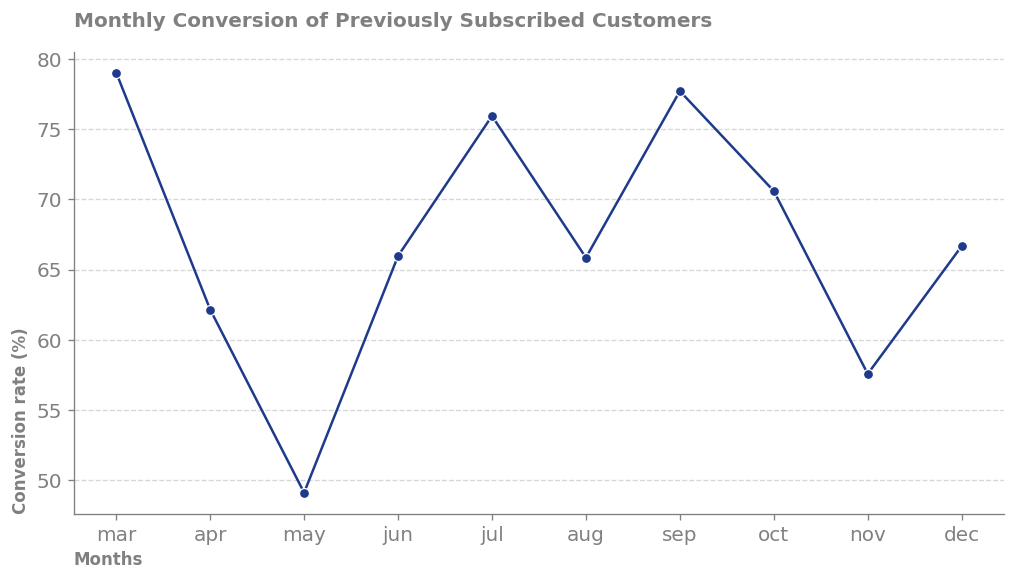

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.lineplot(
    data=conversion_rate_trend,
    x="last_contact_month",
    y="conversion_rate",
    marker="o",
    color='#1E3A8A'
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Monthly Conversion of Previously Subscribed Customers",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=12,
    pad=15
)
ax.set_xlabel("Months"
              , loc="left", weight="bold", color="gray", fontsize=10)
ax.set_ylabel("Conversion rate (%)",
               loc="bottom", weight="bold", color="gray", fontsize=10)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.5)

plt.savefig(FIGURES_DIR / "25.png")
plt.show()

This chart shows the conversion rate by month for customers who successfully subscribed in a previous campaign.

### Key Patterns:

- Highest conversion rates occur in March and September, indicating strong responsiveness from previously subscribed customers during these months.
- Lowest conversion is observed in May, suggesting potential seasonality or campaign timing effects.

### Business Insight:

- Focus follow-up campaigns on previously subscribed customers during high-conversion months to maximize ROI.
- Historical subscription success is a strong predictor of future campaign responsiveness, so targeting this group can improve campaign efficiency.

In [72]:
conversion_rate_by_job = (
    campaigns_outcome
    .query("job != 'unknown'")
    .groupby('job', as_index=False)
    .apply(conversion)
)

conversion_rate_by_job = (
    conversion_rate_by_job.groupby('job')
    .agg(conversion_rate=('conversion_rate','mean'))
    .sort_values('conversion_rate', ascending=False)
    .reset_index()
)

conversion_rate_by_job

C:\Users\asus\AppData\Local\Temp\ipykernel_13740\3480341760.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(conversion)


,job,conversion_rate
0,retired,74.05
1,student,71.19
2,housemaid,71.05
3,management,69.47
4,admin.,66.82
5,unemployed,66.13
6,technician,65.88
7,services,60.00
8,self-employed,53.33
9,blue-collar,49.58


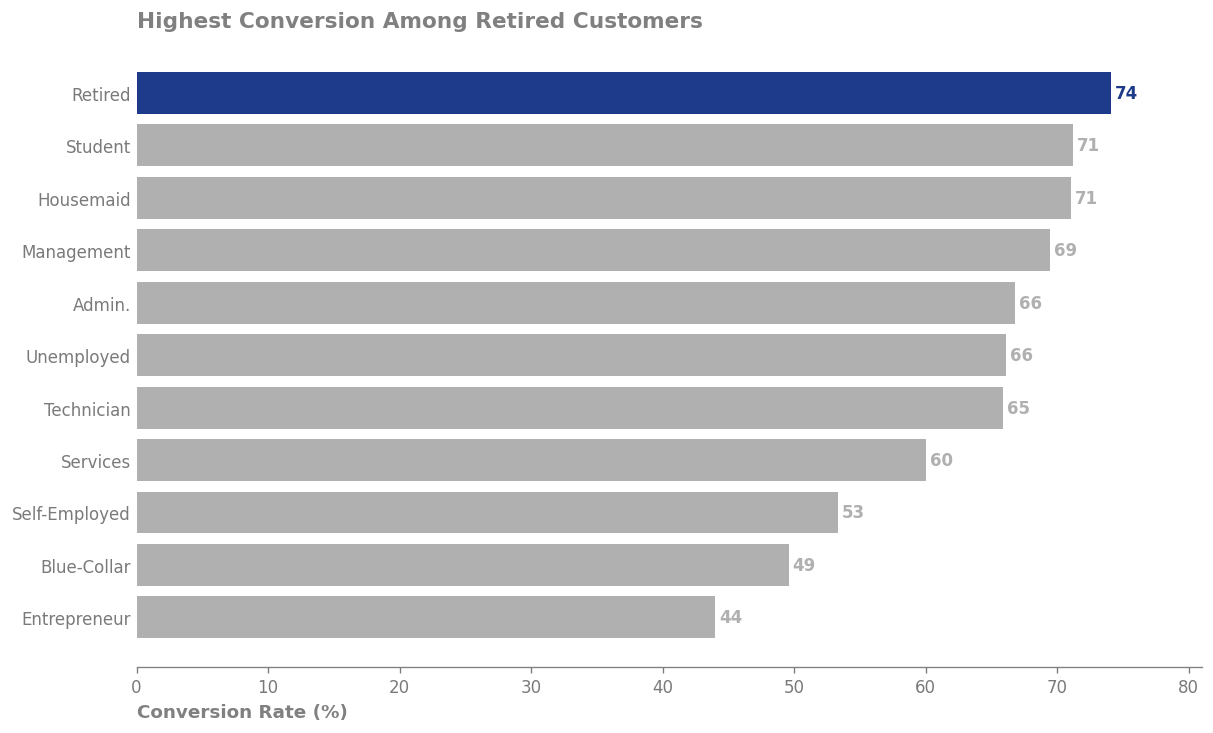

In [73]:
highlight_color = "#1E3A8A"   
base_color = "#B0B0B0"       

colors = [highlight_color] + [base_color] * (len(conversion_rate_by_job) - 1)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.barh(
    conversion_rate_by_job["job"] ,
    conversion_rate_by_job["conversion_rate"],
    color=colors
)

ax.invert_yaxis()

ax.spines[["right", "left", "top"]].set_visible(False)
ax.spines["bottom"].set_color("gray")

ax.set_title(
    "Highest Conversion Among Retired Customers",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="gray",
    pad=10
)

ax.set_xlabel(
    "Conversion Rate (%)",
    loc="left",
    fontsize=11,
    fontweight="bold",
    color="gray",
)

max_x = int(np.ceil(conversion_rate_by_job["conversion_rate"].max() / 2) * 2)
ax.set_xlim(0, max_x+5)

for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = highlight_color if i == 0 else base_color

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.tick_params(axis="y", length=0, colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

ax.set_yticks(ticks=range(len(conversion_rate_by_job["job"])),
              labels=[job.title() for job in conversion_rate_by_job["job"]])

plt.savefig(FIGURES_DIR / "26.png")
plt.show()

### Observations:

- Highest conversion rates: Retired (74%), Students (71%), Housemaids (71%).
- Lowest conversion rates: Entrepreneurs (44%), Blue-Collar workers (49%), Self-Employed (53%).
- General trend: Customers in stable or routine-based jobs tend to convert more successfully compared to self-employed or entrepreneurial roles.

### Business Insights:

- Targeted campaigns: Focus on job categories with historically higher conversion rates to maximize efficiency.
- Customized messaging: For lower-performing job groups, consider tailored offers or communication strategies to improve conversion.
- Resource allocation: Allocate marketing resources based on job-based conversion trends to optimize ROI.


### Economical Features Analysis


In [74]:
bank_marketing_features = df_bank_marketing.drop('age_group', axis=1)

bank_marketing_features.head()

,age,job,marital_status,education_level,has_default,has_housing_loan,has_personal_loan,contact_method,last_contact_month,last_contact_day_of_week,contact_duration,campaign_contacts,days_since_last_contact,previous_campaign_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor3m_rate,nr_employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [75]:
corr_columns = [
    'employment_variation_rate',
    'consumer_price_index',
    'consumer_confidence_index',
    'euribor3m_rate',
    'nr_employed',
    'age',
    'subscribed'
]

In [76]:
corr_matrix = (
    bank_marketing_features[corr_columns].corr()
)

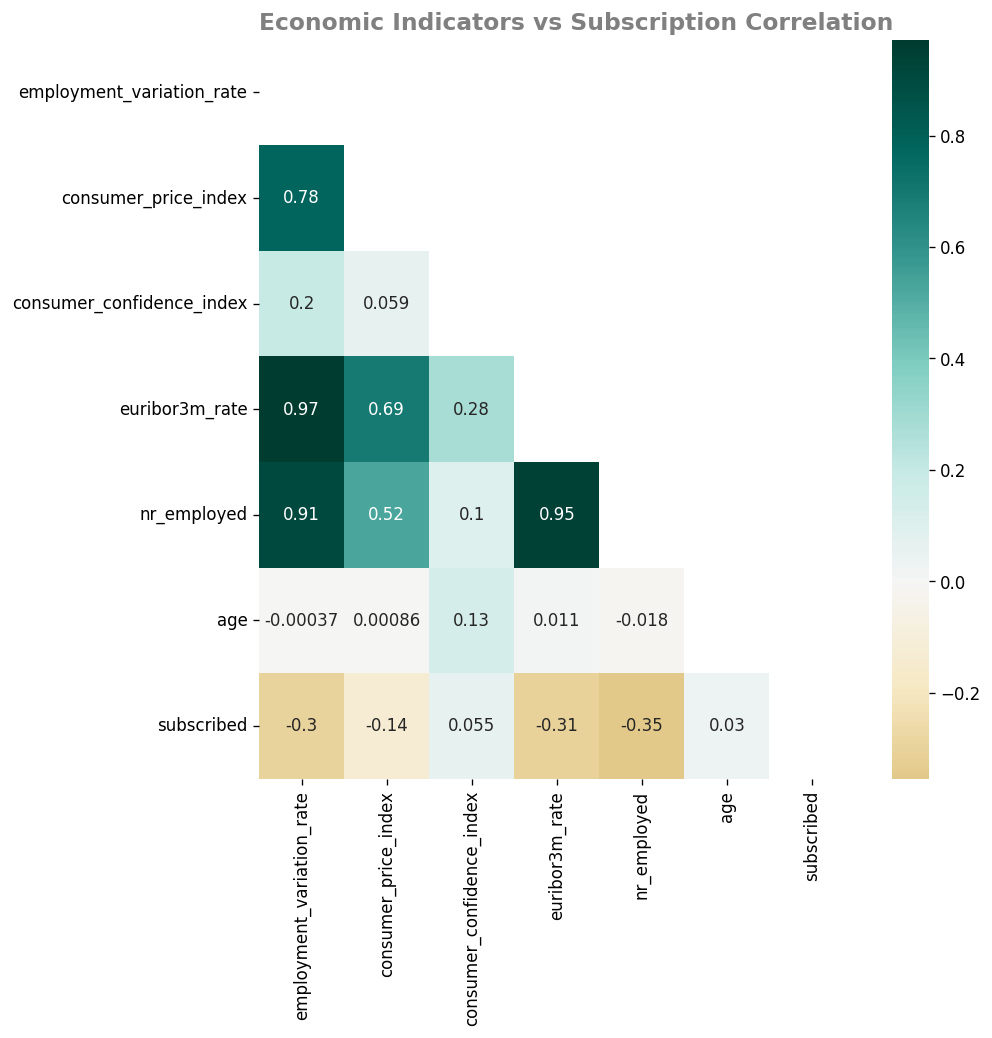

In [77]:
fig, ax = plt.subplots(figsize=(8, 8))

matrix = np.triu(corr_matrix)

ax = sns.heatmap(corr_matrix,
                cmap="BrBG",
                center=0,
                annot=True,
                mask=matrix 
                )

ax.set_title(
    "Economic Indicators vs Subscription Correlation",
    loc="left",
    fontsize=14,
    weight="bold",
    color="gray"
)

plt.savefig(FIGURES_DIR / "27.png")
plt.show()

### Analysis:

- The heatmap shows how various economic indicators relate to subscription behavior.
- Strong positive correlations are observed among economic variables, e.g., euribor3m_rate vs employment (0.95) and euribor3m_rate vs employment_variation_rate (0.97).
- Subscriptions (subscribed) show weak negative correlations with most economic variables:
- nr_employed (-0.35), employment_variation_rate (-0.30), euribor3m_rate (-0.31).
- Age and consumer confidence have minimal influence on subscription decisions.

### Business Insight:

- Subscription decisions are not strongly affected by broad economic indicators in this dataset.
- Focus marketing strategies more on individual and behavioral factors rather than macroeconomic trends.
- Slight negative correlations suggest that higher employment or interest rates may slightly reduce subscription propensity.


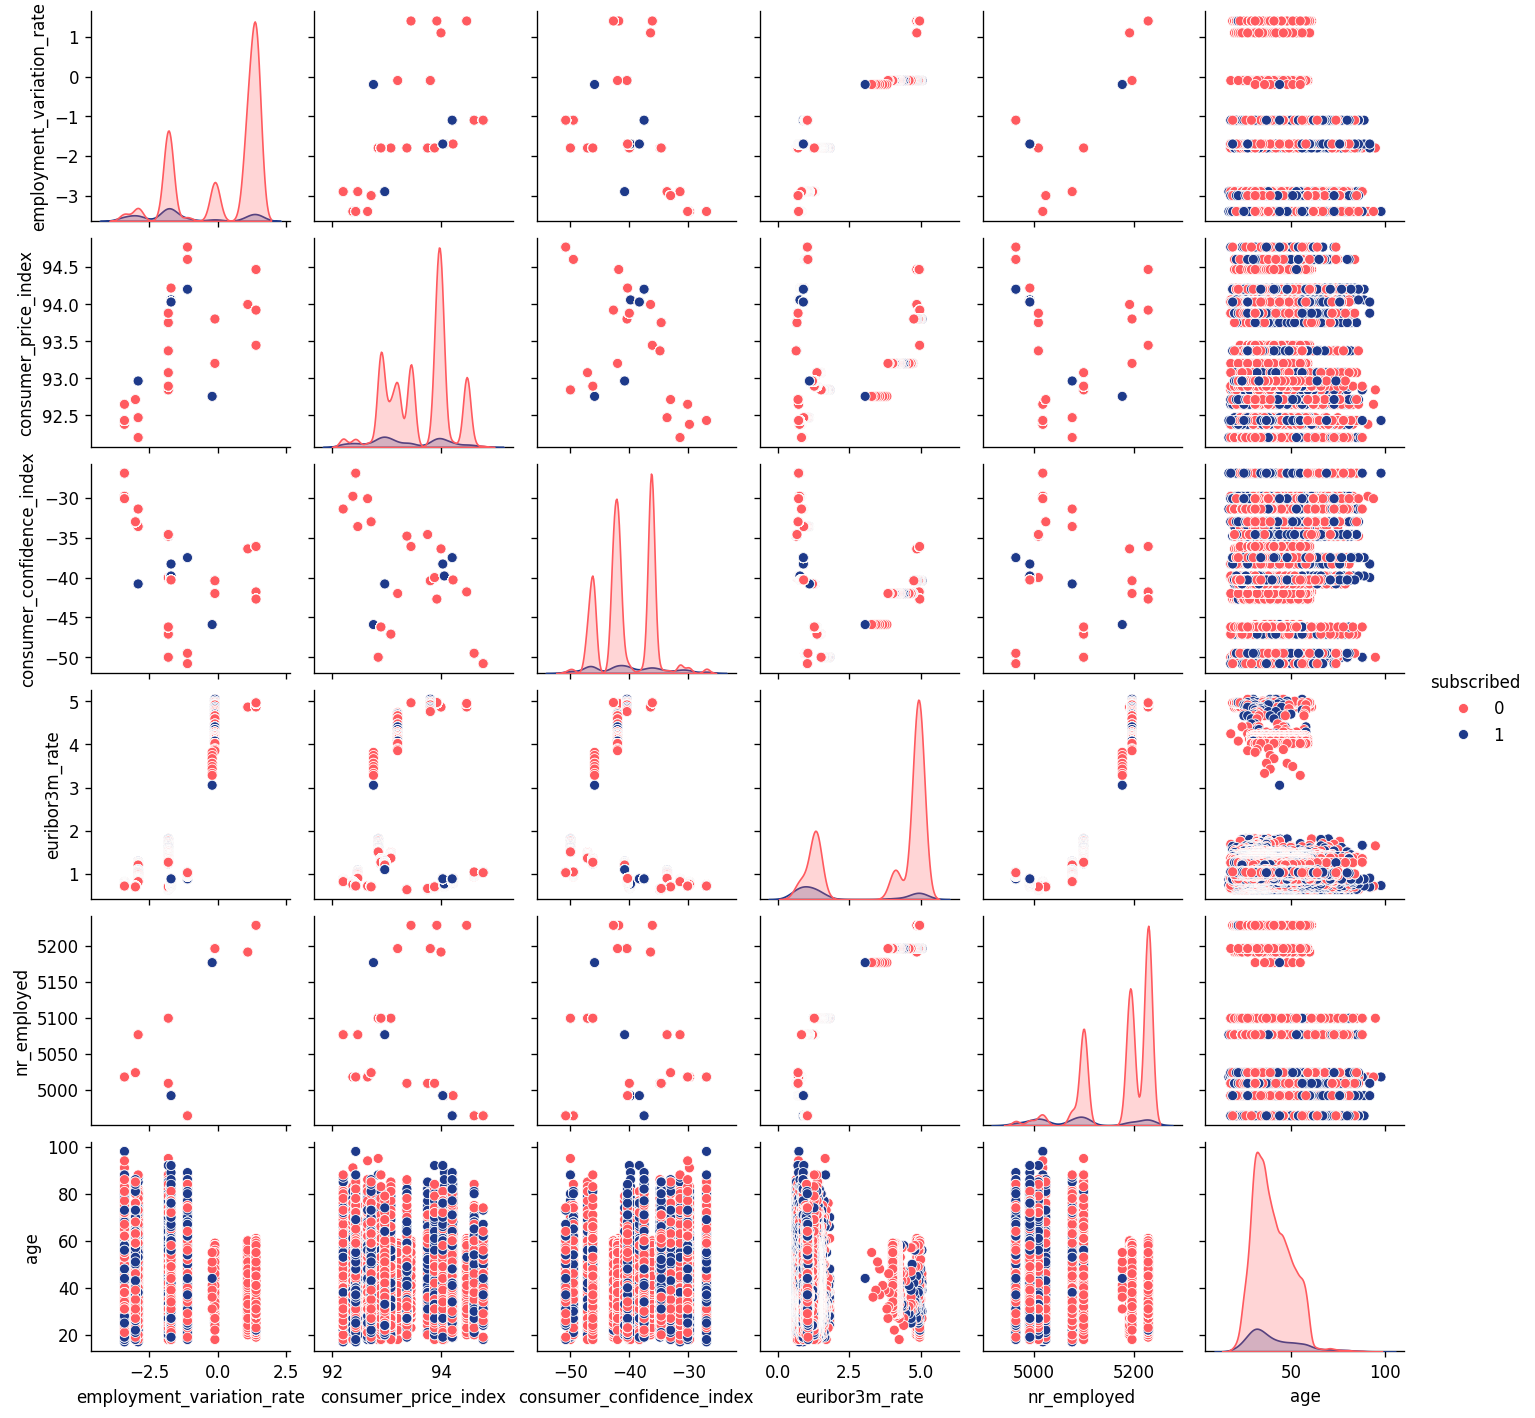

In [78]:
sns.pairplot(bank_marketing_features[corr_columns], 
             hue='subscribed', 
             palette=["#FF5A5F","#1E3A8A"], 
             height=2
)

plt.savefig(FIGURES_DIR / "28.png")
plt.show()

The pair plot visualizes relationships and distributions across all variables simultaneously.

- Diagonal plots show distributions of individual variables.
- Off-diagonal plots allow spotting correlations, trends, and potential patterns between pairs of variables.
- Data points are colored by subscription status to highlight how subscribed and not subscribed customers spread across different variables.

This plot is used for exploratory data analysis (EDA) to detect trends, potential correlations, or clusters before modeling. 
It helps identify which features might be more predictive for subscription behavior.


## Predictive Modeling 

After completing the exploratory analysis, the next step is to build predictive models capable of estimating the likelihood of customer subscription. Because the dataset contains mixed feature types (numerical + categorical), class imbalance, and potentially non‑linear relationships, our modeling workflow will follow a structured and reproducible approach.

### Modeling Objectives

Our primary goals for the modeling phase are:

- Build predictive models that can accurately classify customers into subscribed vs. not subscribed.
- Compare multiple algorithms to find the best balance between accuracy, interpretability, and generalization.
- Use evaluation metrics that reflect the business cost of misclassifying potential subscribers.
- Develop a standardized modeling pipeline that eliminates data leakage and ensures reproducibility.

### Data Preprocessing Strategy

Before training the models, a series of preprocessing steps is required to properly handle the dataset structure:

Numerical Features: 

Scaling is required (MinMaxScaler), especially for distance‑based models such as KNN and margin‑based models like SVM.

Categorical Features:

Categorical variables will be encoded using One‑Hot Encoding for Logistic Regression, KNN, SVM, and Random Forest.

Class Imbalance Handling:

Since the dataset contains fewer “subscribed” cases, the following strategies will be considered:

- Using metrics such as F1-score 
- Applying class_weight='balanced' where supported
- Relying on confusion matrices instead of accuracy alone

Pipeline Construction:

All preprocessing and modeling steps will be encapsulated within unified Scikit‑learn Pipelines to ensure clean cross‑validation and prevent information leakage.


In [79]:
num_cols = [
    'age',
    'employment_variation_rate',
    'consumer_price_index',
    'consumer_confidence_index',
    'euribor3m_rate',
    'nr_employed',
    'campaign_contacts',
    'days_since_last_contact',
    'previous_campaign_contacts',
]

cat_cols = [
    'job',
    'marital_status',
    'education_level',
    'has_default',
    'has_housing_loan',
    'has_personal_loan',
    'contact_method',
    'last_contact_month',
    'last_contact_day_of_week',
    'previous_campaign_outcome'
]

In [80]:
num_pipe = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="mean")),
        ("scale", MinMaxScaler(feature_range=(0,1)))
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("one-hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype="int"))]
)

In [81]:
col_trans = ColumnTransformer(
    transformers=[
        ("num_pipe", num_pipe, num_cols),
        ("cat_pipe", cat_pipe, cat_cols)
    ],
    remainder="drop",
    n_jobs=-1,
)

feature_selector = SelectKBest(chi2)

In [82]:
x = df_bank_marketing[num_cols + cat_cols]
y = df_bank_marketing["subscribed"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

### Models to Be Evaluated

To explore different decision boundaries and learning behaviors, the following models will be trained and compared:

- Logistic Regression: A strong, interpretable baseline suitable for linear relationships.
- Support Vector Machine: Suitable for high‑dimensional feature spaces; included mainly for comparison.
- K‑Nearest Neighbors (KNN): A distance‑based algorithm that benefits from feature scaling; effective in detecting local data patterns.
- Random Forest Classifier: A tree‑based ensemble model capable of handling feature interactions and non‑linearities effectively.

Each model will be trained through an end‑to‑end Pipeline to ensure fair comparison and consistent validation.

### Evaluation Strategy

Given the dataset’s imbalance and the importance of identifying potential subscribers, the following metrics will be emphasized:

- F1-score (binary) – balances precision and recall.
- Confusion Matrix – highlights misclassification patterns.
- ROC-AUC – evaluates ranking performance.

These metrics provide a more realistic assessment than relying solely on accuracy.


### Logistic Regression

In [83]:
log_reg = LogisticRegression(random_state=42, max_iter=10000)

log_reg_pipeline = Pipeline(
    steps=[
        ("col_trans", col_trans),
        ("feature_selector", feature_selector),
        ("model", log_reg),
    ]
)

In [84]:
log_reg_pipeline.fit(x_train, y_train)

,steps,"[('col_trans', ...), ('feature_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_pipe', ...), ('cat_pipe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [85]:
y_pred_train_log_reg = log_reg_pipeline.predict(x_train)

log_reg_accuracy_train = accuracy_score(y_train, y_pred_train_log_reg)
log_reg_precision_train = precision_score(y_train, y_pred_train_log_reg)
log_reg_recall_train = recall_score(y_train, y_pred_train_log_reg)
log_reg_F1_train = f1_score(y_train, y_pred_train_log_reg)

print(f"Logistic Regression Accuracy_train score: {log_reg_accuracy_train:.3f}")
print(f"Logistic Regression Precision_train score: {log_reg_precision_train:.3f}")
print(f"Logistic Regression Recall_train score: {log_reg_recall_train:.3f}")
print(f"Logistic Regression F1_train score: {log_reg_F1_train:.3f}")

Logistic Regression Accuracy_train score: 0.899
Logistic Regression Precision_train score: 0.672
Logistic Regression Recall_train score: 0.197
Logistic Regression F1_train score: 0.305


In [86]:
y_pred_test_log_reg = log_reg_pipeline.predict(x_test)

log_reg_accuracy_test = accuracy_score(y_test, y_pred_test_log_reg)
log_reg_precision_test = precision_score(y_test, y_pred_test_log_reg)
log_reg_recall_test = recall_score(y_test, y_pred_test_log_reg)
log_reg_F1_test = f1_score(y_test, y_pred_test_log_reg)

print(f"Logistic Regression Accuracy_test score: {log_reg_accuracy_test:.3f}")
print(f"Logistic Regression Precision_test score: {log_reg_precision_test:.3f}")
print(f"Logistic Regression Recall_test score: {log_reg_recall_test:.3f}")
print(f"Logistic Regression F1_test score: {log_reg_F1_test:.3f}")

Logistic Regression Accuracy_test score: 0.899
Logistic Regression Precision_test score: 0.683
Logistic Regression Recall_test score: 0.195
Logistic Regression F1_test score: 0.303


In [87]:
param_grid_log_reg = {
    'model__C': np.logspace(-5, 2, 20),
    'model__penalty': ["l1", "l2"],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': ['balanced', None],
    'feature_selector__k': [5, 10, 15, 20]
}

cv = StratifiedKFold(n_splits=5 , shuffle=True, random_state=42) 

In [88]:
grid_search_log_reg = GridSearchCV(
    log_reg_pipeline,
    param_grid=param_grid_log_reg,
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=-1
)

In [89]:
grid_search_log_reg.fit(x_train, y_train)

print("\n--- Best Regression Optimization Results ---")
print(f"Best F1_score of train set: {grid_search_log_reg.best_score_:0.3f}")
print("Best parameter set:")
for param, value in grid_search_log_reg.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 640 candidates, totalling 3200 fits

--- Best Regression Optimization Results ---
Best F1_score of train set: 0.477
Best parameter set:
  feature_selector__k: 10
  model__C: 0.00012742749857031334
  model__class_weight: balanced
  model__penalty: l2
  model__solver: liblinear


In [90]:
y_pred_proba = grid_search_log_reg.best_estimator_.predict_proba(x_test)[:,1]

prec, rec, thr = precision_recall_curve(y_test, y_pred_proba) 

In [91]:
F1_scores = []
for t in thr:
    y_pred_at_threshold = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_at_threshold)
    F1_scores.append(f1)

F1_scores = np.array(F1_scores)
thr = np.array(thr)

best_f1_index = np.argmax(F1_scores)
best_threshold = thr[best_f1_index]
best_f1_score = F1_scores[best_f1_index]

print(f"The best threshold found for the model: {best_threshold:.3f}")

The best threshold found for the model: 0.506


In [92]:
y_pred_best_threshold = (y_pred_proba >= best_threshold).astype(int)

In [93]:
log_reg_accuracy_test = accuracy_score(y_test, y_pred_best_threshold)
log_reg_precision_test = precision_score(y_test, y_pred_best_threshold)
log_reg_recall_test = recall_score(y_test, y_pred_best_threshold)
log_reg_F1_test = f1_score(y_test, y_pred_best_threshold)

print(f"Logistic Regression Accuracy_test score: {log_reg_accuracy_test:.3f}")
print(f"Logistic Regression Precision_test score: {log_reg_precision_test:.3f}")
print(f"Logistic Regression Recall_test score: {log_reg_recall_test:.3f}")
print(f"Logistic Regression F1_test score: {log_reg_F1_test:.3f}")

Logistic Regression Accuracy_test score: 0.880
Logistic Regression Precision_test score: 0.471
Logistic Regression Recall_test score: 0.517
Logistic Regression F1_test score: 0.493


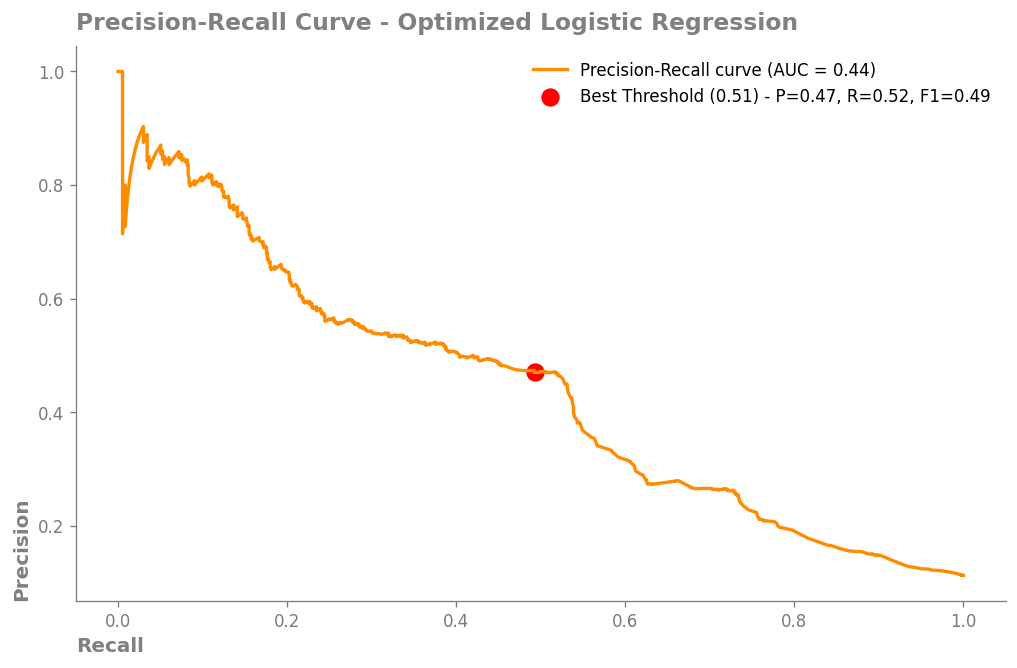

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))

auc_score = auc(rec, prec)
plt.plot(rec, prec, color='darkorange', lw=2, label=f'Precision-Recall curve (AUC = {auc_score:.2f})')

plt.scatter(
    log_reg_F1_test, 
    log_reg_precision_test, 
    marker='o', 
    color='red', 
    s=100, 
    label=f'Best Threshold ({best_threshold:.2f}) - P={log_reg_precision_test:.2f}, R={log_reg_recall_test:.2f}, F1={log_reg_F1_test:.2f}')

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

plt.title(
    "Precision-Recall Curve - Optimized Logistic Regression",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="gray",
    pad=10)

plt.xlabel(
    "Recall",
    loc="left",
    fontsize=12,
    fontweight="bold",
    color="gray")

plt.ylabel(
    "Precision",
    loc="bottom",
    fontsize=12,
    fontweight="bold",
    color="gray")

ax.tick_params(axis="y", colors="#7A7A7A")
ax.tick_params(axis="x", colors="#7A7A7A")

plt.legend(loc="upper right", frameon=False)

plt.savefig(FIGURES_DIR / "29.png")
plt.show()

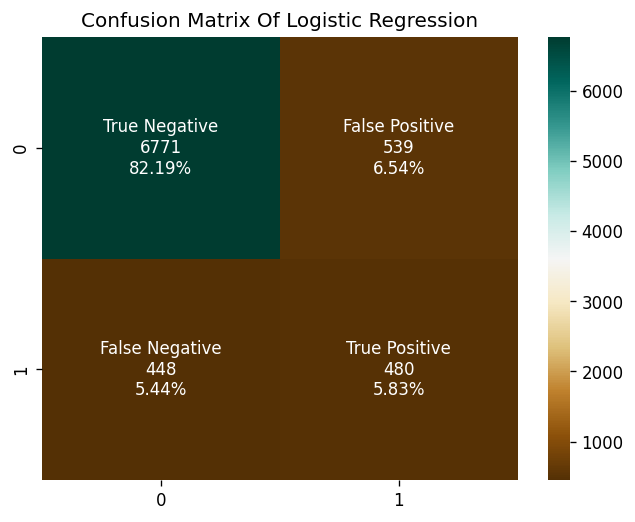

In [95]:
log_reg_confusion_matrix = confusion_matrix(y_test, y_pred_best_threshold)

group_names = ["True Negative", "False Positive", "False Negative", "True Positive"]
group_counts = [
    value for value in log_reg_confusion_matrix.flatten()
]
group_percentages = [
    "{0:.2%}".format(value)
    for value in log_reg_confusion_matrix.flatten() / np.sum(log_reg_confusion_matrix)
]
labels = [
    f"{v1}\n{v2}\n{v3}"
    for v1, v2, v3 in zip(group_names, group_counts, group_percentages)
]
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(log_reg_confusion_matrix, annot=labels, fmt="", cmap="BrBG")
plt.title("Confusion Matrix Of Logistic Regression")

plt.savefig(FIGURES_DIR / "30.png")
plt.show()

### SVM

In [96]:
svc = SVC(random_state=42, class_weight = 'balanced')
svc_pipe = Pipeline(
    steps=[
        ("col_trans", col_trans),
        ("feature_selector", feature_selector),
        ("model", svc)
    ]
)

In [97]:
svc_params = {
    "model__C": [0.1, 1, 10, 100, 1000, 10000],
    "model__gamma": [0.001, 0.01, 0.1, 1, 10],
    "model__kernel": ['rbf', 'linear']
}

cv = StratifiedKFold(n_splits=5 , shuffle=True, random_state=42) 

In [98]:
svc_grid_search = GridSearchCV(
    svc_pipe,
    svc_params,
    cv=cv,
    scoring='f1', 
    verbose=True,
    n_jobs=-1,
)

In [99]:
svc_grid_search.fit(x_train, y_train)

print("\n--- Best SVM Optimization Results ---")
print(f"Best F1-Score: {svc_grid_search.best_score_:.3f}")
print("Best parameter set:")
for param, value in svc_grid_search.best_params_.items():
    print(f"  {param}: {value}") 

Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Best SVM Optimization Results ---
Best F1-Score: 0.465
Best parameter set:
  model__C: 1000
  model__gamma: 0.1
  model__kernel: rbf


In [100]:
y_pred_train_svc = svc_grid_search.best_estimator_.predict(x_train)

svc_accuracy_train = accuracy_score(y_train, y_pred_train_svc)
svc_precision_train = precision_score(y_train, y_pred_train_svc, zero_division=0)
svc_recall_train = recall_score(y_train, y_pred_train_svc, zero_division=0)
svc_F1_train = f1_score(y_train, y_pred_train_svc, zero_division=0)

print(f"SVC Accuracy_train score: {svc_accuracy_train:.3f}")
print(f"SVC Precision_train score: {svc_precision_train:.3f}")
print(f"SVC Recall_train score: {svc_recall_train:.3f}")
print(f"SVC F1_train score: {svc_F1_train:.3f}")

SVC Accuracy_train score: 0.872
SVC Precision_train score: 0.443
SVC Recall_train score: 0.539
SVC F1_train score: 0.486


In [101]:
y_pred_test_svc = svc_grid_search.best_estimator_.predict(x_test)

svc_accuracy_test = accuracy_score(y_test, y_pred_test_svc)
svc_precision_test = precision_score(y_test, y_pred_test_svc, zero_division=0)
svc_recall_test = recall_score(y_test, y_pred_test_svc, zero_division=0)
svc_F1_test = f1_score(y_test, y_pred_test_svc, zero_division=0)

print(f"SVC Accuracy_test score: {svc_accuracy_test:.3f}")
print(f"SVC Precision_test score: {svc_precision_test:.3f}")
print(f"SVC Recall_test score: {svc_recall_test:.3f}")
print(f"SVC F1_test score: {svc_F1_test:.3f}")

SVC Accuracy_test score: 0.875
SVC Precision_test score: 0.455
SVC Recall_test score: 0.546
SVC F1_test score: 0.496


In [102]:
print("Classification Report:")
print(classification_report(y_test, y_pred_test_svc))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7310
           1       0.45      0.55      0.50       928

    accuracy                           0.88      8238
   macro avg       0.70      0.73      0.71      8238
weighted avg       0.89      0.88      0.88      8238



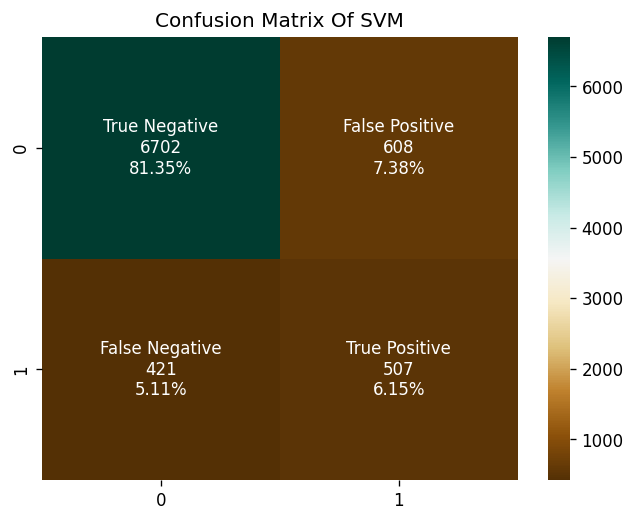

In [103]:
svc_confusion_matrix = confusion_matrix(y_test, y_pred_test_svc)

group_names = ["True Negative", "False Positive", "False Negative", "True Positive"]
group_counts = [
    value for value in svc_confusion_matrix.flatten()
]
group_percentages = [
    "{0:.2%}".format(value)
    for value in svc_confusion_matrix.flatten() / np.sum(svc_confusion_matrix)
]
labels = [
    f"{v1}\n{v2}\n{v3}"
    for v1, v2, v3 in zip(group_names, group_counts, group_percentages)
]
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(svc_confusion_matrix, annot=labels, fmt="", cmap="BrBG")
plt.title("Confusion Matrix Of SVM")

plt.savefig(FIGURES_DIR / "31.png")
plt.show()

### KNN

In [104]:
knn = KNeighborsClassifier()

knn_pipeline = Pipeline(
    steps=[
        ("col_trans", col_trans),
        ("feature_selector", feature_selector),
        ("model", knn),
    ]
)

In [105]:
knn_pipeline.fit(x_train, y_train)

,steps,"[('col_trans', ...), ('feature_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_pipe', ...), ('cat_pipe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15],
    'model__weights': ["uniform", "distance"],
    'model__p': [1, 2, 3],
}

In [107]:
grid_search_knn = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid_knn,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [108]:
grid_search_knn.fit(x_train, y_train)

print("\n--- Best KNN Optimization Results ---")
print(f"Best F1_score of train set: {grid_search_knn.best_score_:0.3f}")
print("Best parameter set:")
for param, value in grid_search_knn.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- Best KNN Optimization Results ---
Best F1_score of train set: 0.392
Best parameter set:
  model__n_neighbors: 5
  model__p: 1
  model__weights: uniform


In [109]:
y_pred_train_knn = grid_search_knn.best_estimator_.predict(x_train)

knn_accuracy_train = accuracy_score(y_train, y_pred_train_knn)
knn_precision_train = precision_score(y_train, y_pred_train_knn, zero_division=0)
knn_recall_train = recall_score(y_train, y_pred_train_knn, zero_division=0)
knn_F1_train = f1_score(y_train, y_pred_train_knn, zero_division=0)

print(f"KNN Accuracy_train score: {knn_accuracy_train:.3f}")
print(f"KNN Precision_train score: {knn_precision_train:.3f}")
print(f"KNN Recall_train score: {knn_recall_train:.3f}")
print(f"KNN F1_train score: {knn_F1_train:.3f}")

KNN Accuracy_train score: 0.908
KNN Precision_train score: 0.669
KNN Recall_train score: 0.363
KNN F1_train score: 0.470


In [110]:
y_pred_test_knn = grid_search_knn.best_estimator_.predict(x_test)

knn_accuracy_test = accuracy_score(y_test, y_pred_test_knn)
knn_precision_test = precision_score(y_test, y_pred_test_knn)
knn_recall_test = recall_score(y_test, y_pred_test_knn)
knn_F1_test = f1_score(y_test, y_pred_test_knn)

print(f"KNN Accuracy_test score: {knn_accuracy_test:.3f}")
print(f"KNN Precision_test score: {knn_precision_test:.3f}")
print(f"KNN Recall_test score: {knn_recall_test:.3f}")
print(f"KNN F1_test score: {knn_F1_test:.3f}")

KNN Accuracy_test score: 0.896
KNN Precision_test score: 0.573
KNN Recall_test score: 0.309
KNN F1_test score: 0.402


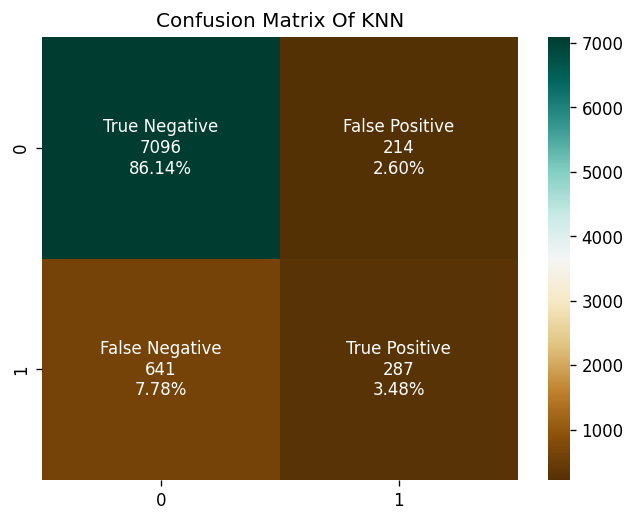

In [111]:
knn_confusion_matrix = confusion_matrix(y_test, y_pred_test_knn)

group_names = ["True Negative", "False Positive", "False Negative", "True Positive"]
group_counts = [
    value for value in knn_confusion_matrix.flatten()
]
group_percentages = [
    "{0:.2%}".format(value)
    for value in knn_confusion_matrix.flatten() / np.sum(knn_confusion_matrix)
]
labels = [
    f"{v1}\n{v2}\n{v3}"
    for v1, v2, v3 in zip(group_names, group_counts, group_percentages)
]
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(knn_confusion_matrix, annot=labels, fmt="", cmap="BrBG")
plt.title("Confusion Matrix Of KNN")

plt.savefig(FIGURES_DIR / "32.png")
plt.show()

### Random Forest

In [112]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_pipeline = Pipeline(
    steps=[
        ("col_trans", col_trans),
        ("feature_selector", feature_selector),
        ("model", rf),
    ]
)

In [113]:
rf_pipeline.fit(x_train, y_train)

,steps,"[('col_trans', ...), ('feature_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_pipe', ...), ('cat_pipe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [114]:
param_grid_rf = {
    "model__n_estimators" : [100, 300, 500], 
    'model__max_features': ['sqrt', 'log2', 0.8],
    "model__max_depth" : [5, 10, None] , 
    "model__min_samples_split" : [2, 5, 10],
    'model__min_samples_leaf': [1, 3, 5, 7],
}

In [115]:
grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [116]:
grid_search_rf.fit(x_train, y_train)

print("\n--- Best Random Forest Optimization Results ---")
print(f"Best F1_score of train set: {grid_search_rf.best_score_:0.3f}")
print("Best parameter set:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

--- Best Random Forest Optimization Results ---
Best F1_score of train set: 0.462
Best parameter set:
  model__max_depth: 10
  model__max_features: sqrt
  model__min_samples_leaf: 5
  model__min_samples_split: 2
  model__n_estimators: 300


In [117]:
y_pred_train_rf = grid_search_rf.best_estimator_.predict(x_train)

rf_accuracy_train = accuracy_score(y_train, y_pred_train_rf)
rf_precision_train = precision_score(y_train, y_pred_train_rf)
rf_recall_train = recall_score(y_train, y_pred_train_rf)
rf_F1_train = f1_score(y_train, y_pred_train_rf)

print(f"RF Accuracy_train score: {rf_accuracy_train:.3f}")
print(f"RF Precision_train score: {rf_precision_train:.3f}")
print(f"RF Recall_train score: {rf_recall_train:.3f}")
print(f"RF F1_train score: {rf_F1_train:.3f}")

RF Accuracy_train score: 0.843
RF Precision_train score: 0.382
RF Recall_train score: 0.630
RF F1_train score: 0.475


In [118]:
y_pred_test_rf = grid_search_rf.best_estimator_.predict(x_test)

rf_accuracy_test = accuracy_score(y_test, y_pred_test_rf)
rf_precision_test = precision_score(y_test, y_pred_test_rf)
rf_recall_test = recall_score(y_test, y_pred_test_rf)
rf_F1_test = f1_score(y_test, y_pred_test_rf)

print(f"RF Accuracy_test score: {rf_accuracy_test:.3f}")
print(f"RF Precision_test score: {rf_precision_test:.3f}")
print(f"RF Recall_test score:rf: {rf_recall_test:.3f}")
print(f"RF F1_test score:rf: {rf_F1_test:.3f}")

RF Accuracy_test score: 0.847
RF Precision_test score: 0.391
RF Recall_test score:rf: 0.643
RF F1_test score:rf: 0.486


In [119]:
print("Classification Report:")
print(classification_report(y_test, y_pred_test_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.64      0.49       928

    accuracy                           0.85      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.85      0.86      8238



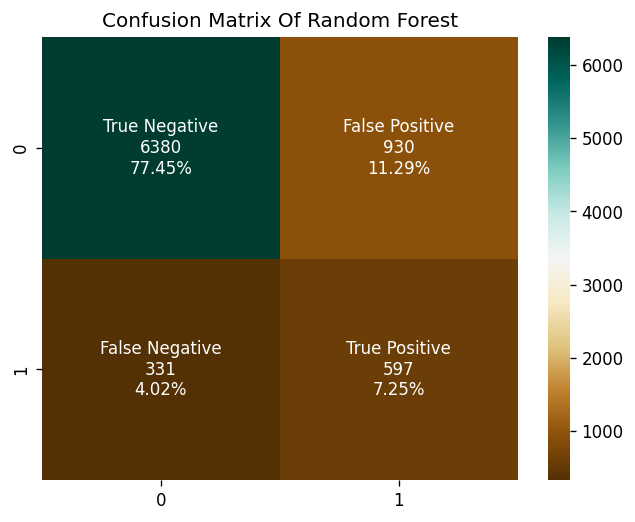

In [120]:
rf_confusion_matrix = confusion_matrix(y_test, y_pred_test_rf)

group_names = ["True Negative", "False Positive", "False Negative", "True Positive"]
group_counts = [
    value for value in rf_confusion_matrix.flatten()
]
group_percentages = [
    "{0:.2%}".format(value)
    for value in rf_confusion_matrix.flatten() / np.sum(rf_confusion_matrix)
]
labels = [
    f"{v1}\n{v2}\n{v3}"
    for v1, v2, v3 in zip(group_names, group_counts, group_percentages)
]
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(rf_confusion_matrix, annot=labels, fmt="", cmap="BrBG")
plt.title("Confusion Matrix Of Random Forest")

plt.savefig(FIGURES_DIR / "33.png")
plt.show()